In [1]:
# XGBoost_Aurora.py
# -------------------------------------------------------------
# Tuned XGBoost for aurora intensity prediction
# COMPSCI 760 — Group 10
# -------------------------------------------------------------

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# -------------------------------------------------------------
# 0. Global knobs
# -------------------------------------------------------------
PIPELINE_MODE = True
REFIT_METRIC = "mae"   # or "rmse"

FAST_MODE   = True
CPU_COUNT   = os.cpu_count() or 2
N_JOBS      = min(4, CPU_COUNT)
N_SPLITS    = 2 if FAST_MODE else 3
N_ITER      = 20 if FAST_MODE else 50

# -------------------------------------------------------------
# 1. Load dataset (from Kaggle input)
# -------------------------------------------------------------
BASE_DIR = "/kaggle/input/final-planb-24"
CSV_PATH = os.path.join(BASE_DIR, "final-planb-24.csv")

df = pd.read_csv(CSV_PATH, parse_dates=["time"])
print("Loaded:", CSV_PATH)
print("Shape before drop:", df.shape)
print("Time range:", df["time"].min(), "->", df["time"].max())

# -------------------------------------------------------------
# 2. Define target/features
# -------------------------------------------------------------
TARGET_COL = "keogram_mean"
df = df.dropna(subset=[TARGET_COL]).copy()

drop_cols = ["time", "keogram_mean", "keogram_median", "keogram_max"]
features = [c for c in df.columns if c not in drop_cols]

X_all = df[features]

# -------------------------------------------------------------
# 3. Time-based split
# -------------------------------------------------------------
train_idx = df[(df["time"] < "2018-01-01")].index
val_idx   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].index
test_idx  = df[(df["time"] >= "2019-01-01") & (df["time"] < "2021-01-01")].index

X_train_df = X_all.loc[train_idx]
X_val_df   = X_all.loc[val_idx]
X_test_df  = X_all.loc[test_idx]

y_train = df.loc[train_idx, TARGET_COL].values
y_val   = df.loc[val_idx, TARGET_COL].values
y_test  = df.loc[test_idx, TARGET_COL].values

if not PIPELINE_MODE:
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train_df)
    X_val   = imputer.transform(X_val_df)
    X_test  = imputer.transform(X_test_df)
else:
    X_train, X_val, X_test = X_train_df, X_val_df, X_test_df

print("Split sizes:",
      "train =", len(train_idx),
      "val =", len(val_idx),
      "test =", len(test_idx))

# -------------------------------------------------------------
# 4. Hyperparameter search
# -------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}

param_space = {
    "xgb__n_estimators": [300, 600, 900] if FAST_MODE else [300, 600, 900, 1200],
    "xgb__max_depth": [3, 6, 9] if FAST_MODE else [3, 6, 9, 12],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
    "xgb__subsample": [0.7, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.9, 1.0],
    "xgb__min_child_weight": [1, 3, 5],
    "xgb__gamma": [0, 0.1, 0.3],
    "xgb__reg_lambda": [1, 5, 10],
}

base_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=N_JOBS,
    tree_method="gpu_hist",    # GPU acceleration
    predictor="gpu_predictor"
)

if PIPELINE_MODE:
    estimator = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("xgb", base_xgb)
    ])
else:
    estimator = base_xgb

search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_space,
    n_iter=N_ITER,
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    n_jobs=N_JOBS,
    verbose=1,
    random_state=42,
)

print("\n[Search] XGBoost ...")
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print(f"Best CV {REFIT_METRIC.upper()}: {-search.best_score_:.4f}")

best_estimator = search.best_estimator_

# -------------------------------------------------------------
# 5. Evaluate
# -------------------------------------------------------------
def eval_and_print(split_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{split_name} -> MSE: {mse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")

val_pred  = best_estimator.predict(X_val_df if PIPELINE_MODE else X_val)
test_pred = best_estimator.predict(X_test_df if PIPELINE_MODE else X_test)

print("\n=== Evaluation ===")
eval_and_print("VAL ", y_val, val_pred)
eval_and_print("TEST", y_test, test_pred)

# -------------------------------------------------------------
# 6. Baselines
# -------------------------------------------------------------
def baseline_report(y_true, name="mean"):
    if name == "mean":
        yhat = np.full_like(y_true, np.mean(y_true), dtype=float)
    elif name == "median":
        yhat = np.full_like(y_true, np.median(y_true), dtype=float)
    mse = mean_squared_error(y_true, yhat)
    mae = mean_absolute_error(y_true, yhat)
    rmse = np.sqrt(mse)
    print(f"Baseline ({name}) -> RMSE: {rmse:.4f}  MAE: {mae:.4f}")

print("\n=== Baselines ===")
baseline_report(y_val, "mean")
baseline_report(y_val, "median")
baseline_report(y_test, "mean")
baseline_report(y_test, "median")

# -------------------------------------------------------------
# 7. Feature importances
# -------------------------------------------------------------
if PIPELINE_MODE:
    model = best_estimator.named_steps["xgb"]
else:
    model = best_estimator

importances = model.feature_importances_
order = np.argsort(importances)[::-1][:15]
print("\nTop-15 features:")
for idx in order:
    print(f"{features[idx]:20s} {importances[idx]:.4f}")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/final-planb-24/final-planb-24.csv'

In [3]:
# XGBoost_LogFix.py
# -------------------------------------------------------------
# XGBoost for aurora intensity prediction (with log1p target transform)
# Author: Group 10 (COMPSCI 760) — Kaggle-ready
# -------------------------------------------------------------

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# -------------------------------------------------------------
# 0. Global knobs
# -------------------------------------------------------------
PIPELINE_MODE = True
REFIT_METRIC = "mae"
FAST_MODE = True
N_SPLITS = 2 if FAST_MODE else 3
N_JOBS = 4

# -------------------------------------------------------------
# 1. Load dataset
# -------------------------------------------------------------
BASE_DIR = "/kaggle/input/final-planb-24"
CSV_PATH = os.path.join(BASE_DIR, "final-planb-24.csv")

df = pd.read_csv(CSV_PATH, parse_dates=["time"])
print("Loaded:", CSV_PATH)
print("Shape before drop:", df.shape)
print("Time range:", df["time"].min(), "->", df["time"].max(), flush=True)

# -------------------------------------------------------------
# 2. Target + features
# -------------------------------------------------------------
TARGET_COL = "keogram_mean"

# Drop rows with NaN target
before = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()
after = len(df)
print(f"Dropped rows with NaN target ({TARGET_COL}): {before - after}", flush=True)

# Drop columns not usable as features
drop_cols = ["time", "keogram_mean", "keogram_median", "keogram_max"]
features = [c for c in df.columns if c not in drop_cols]
X_all = df[features]

# -------------------------------------------------------------
# 3. Time-based splits
# -------------------------------------------------------------
train_idx = df[(df["time"] < "2018-01-01")].index
val_idx   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].index
test_idx  = df[(df["time"] >= "2019-01-01") & (df["time"] < "2021-01-01")].index

print("Split sizes:",
      "train =", len(train_idx),
      "val =", len(val_idx),
      "test =", len(test_idx), flush=True)

X_train_df, X_val_df, X_test_df = (
    X_all.loc[train_idx],
    X_all.loc[val_idx],
    X_all.loc[test_idx],
)

# ✅ Fixed indexing (slice from df, not y_all)
y_train = np.log1p(df.loc[train_idx, TARGET_COL].values)
y_val   = np.log1p(df.loc[val_idx, TARGET_COL].values)
y_test  = np.log1p(df.loc[test_idx, TARGET_COL].values)

# -------------------------------------------------------------
# 4. Model + Hyperparameter search
# -------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

param_dist = {
    "xgb__n_estimators": [300, 600] if FAST_MODE else [300, 600, 900],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.7, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.9, 1.0],
    "xgb__gamma": [0, 0.1, 0.3],
    "xgb__min_child_weight": [1, 3],
    "xgb__reg_lambda": [1, 5, 10],
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="gpu_hist",  # fast + GPU-ready
    random_state=42,
    n_jobs=N_JOBS,
)

pipe = Pipeline(steps=[("imp", SimpleImputer(strategy="median")), ("xgb", xgb)])

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20 if FAST_MODE else 40,
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    verbose=1,
    random_state=42,
    n_jobs=N_JOBS,
)

print("\n[Search] XGBoost ...")
search.fit(X_train_df, y_train)

print("Best params:", search.best_params_)
print(f"Best CV {REFIT_METRIC.upper()}: {-search.best_score_:.4f}")

best_estimator = search.best_estimator_

# -------------------------------------------------------------
# 5. Evaluation
# -------------------------------------------------------------
def eval_and_print(name, y_true, y_pred_log):
    # invert log1p
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_log)

    mse = mean_squared_error(y_true_orig, y_pred_orig)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2  = r2_score(y_true_orig, y_pred_orig)
    print(f"{name} -> MSE: {mse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}", flush=True)

print("\n=== Evaluation ===", flush=True)
eval_and_print("VAL ", y_val, best_estimator.predict(X_val_df))
eval_and_print("TEST", y_test, best_estimator.predict(X_test_df))

# -------------------------------------------------------------
# 6. Feature importances
# -------------------------------------------------------------
xgb_model = best_estimator.named_steps["xgb"]
importances = xgb_model.feature_importances_
order = np.argsort(importances)[::-1][:15]
print("\nTop-15 features:")
for i in order:
    print(f"{features[i]:20s}  {importances[i]:.4f}")


Loaded: /kaggle/input/final-planb-24/final-planb-24.csv
Shape before drop: (78957, 23)
Time range: 2012-01-01 00:00:00 -> 2021-01-01 05:00:00
Dropped rows with NaN target (keogram_mean): 68813
Split sizes: train = 7430 val = 849 test = 1865

[Search] XGBoost ...
Fitting 2 folds for each of 20 candidates, totalling 40 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:47:42] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:47:42] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:47:42] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserW

Best params: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 10, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 3, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.3, 'xgb__colsample_bytree': 0.9}
Best CV MAE: 0.4270

=== Evaluation ===
VAL  -> MSE: 545.6938  MAE: 15.5158  R2: 0.1983
TEST -> MSE: 445.3672  MAE: 14.8362  R2: 0.1928

Top-15 features:
Kp                    0.4104
ap                    0.0949
tp_mm_mean_aw         0.0544
tp_mm_median          0.0487
tp_mm_max             0.0429
tp_mm_p75             0.0413
tcc_mean              0.0388
tcc_median            0.0314
humidity_max          0.0304
tcc_p75               0.0261
humidity_p75          0.0259
temp_p75              0.0254
temp_mean             0.0245
temp_median           0.0242
temp_max              0.0234


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:48:42] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:48:42] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [4]:
from xgboost import XGBRegressor

# -------------------------------------------------------------
# GPU-optimized XGBRegressor (faster + deeper search)
# -------------------------------------------------------------
xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="gpu_hist",   # << use GPU histogram algorithm
    predictor="gpu_predictor",# << prediction on GPU as well
    random_state=42,
    n_jobs=N_JOBS,
)

pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("xgb", xgb),
])

# Expanded search space (balanced for Kaggle GPU)
param_dist = {
    "xgb__n_estimators": [500, 1000, 1500],      # more boosting rounds
    "xgb__learning_rate": [0.01, 0.03, 0.05],    # smaller LR with more trees
    "xgb__max_depth": [4, 6, 8],                 # allow deeper trees
    "xgb__min_child_weight": [1, 3, 5],          # regularization
    "xgb__subsample": [0.7, 0.9, 1.0],           # row sampling
    "xgb__colsample_bytree": [0.7, 0.9, 1.0],    # feature sampling
    "xgb__gamma": [0, 0.1, 0.3],                 # split regularization
    "xgb__reg_lambda": [1, 5, 10],               # L2 regularization
    "xgb__reg_alpha": [0, 0.1, 1],               # L1 regularization
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,                   # more iterations (GPU can handle this)
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    verbose=2,
    random_state=42,
    n_jobs=N_JOBS,
)

print("\n[Search] GPU-Optimized XGBoost ...")
search.fit(X_train_df, y_train)



[Search] GPU-Optimized XGBoost ...
Fitting 2 folds for each of 30 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:54:43] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:54:43] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:54:43] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserW

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=2, test_size=None),
                   estimator=Pipeline(steps=[('imp',
                                              SimpleImputer(strategy='median')),
                                             ('xgb',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=None,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=Fal...
                                        'xgb__gamma': [0, 0.1, 0.3],
                                        'xgb__learning_rate': [0.01, 0.03,
                                                               0.05],
                                        'xgb__max_depth': [4, 6, 8],
                                        'xgb__min_child_weight': [1, 3, 5],
                                        'xgb__n_estimators': [500, 1000, 1500],
                                        'xgb__reg_alpha': [0, 0.1, 1],
                                        'xgb__reg_lambda': [1, 5, 10],
                                        'xgb__subsample': [0.7, 0.9, 1.0]},
                   random_state=42, refit='mae',
                   scoring={'mae': 'neg_mean_absolute_error',
                            'rmse': 'neg_root_mean_squared_error'},
                   verbose=2)

[CV] END xgb__colsample_bytree=1.0, xgb__gamma=0.1, xgb__learning_rate=0.01, xgb__max_depth=8, xgb__min_child_weight=1, xgb__n_estimators=500, xgb__reg_alpha=0, xgb__reg_lambda=1, xgb__subsample=0.7; total time=  13.6s
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.3, xgb__learning_rate=0.03, xgb__max_depth=6, xgb__min_child_weight=1, xgb__n_estimators=1000, xgb__reg_alpha=0.1, xgb__reg_lambda=10, xgb__subsample=1.0; total time=  10.0s
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.3, xgb__learning_rate=0.01, xgb__max_depth=6, xgb__min_child_weight=3, xgb__n_estimators=500, xgb__reg_alpha=1, xgb__reg_lambda=10, xgb__subsample=0.9; total time=   9.7s
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.3, xgb__learning_rate=0.05, xgb__max_depth=6, xgb__min_child_weight=5, xgb__n_estimators=1000, xgb__reg_alpha=0, xgb__reg_lambda=1, xgb__subsample=0.9; total time=   9.7s
[CV] END xgb__colsample_bytree=1.0, xgb__gamma=0, xgb__learning_rate=0.03, xgb__max_depth=8, xgb__min_child_weight=3, 

In [1]:
# XGBoost_FullVis.py
# -------------------------------------------------------------
# XGBoost for aurora intensity prediction (with log1p target transform)
# + Visualizations and comparison tables (like RandomForest.py)
# Author: Group 10 (COMPSCI 760) — Kaggle-ready
# -------------------------------------------------------------

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# 0. Global knobs
# -------------------------------------------------------------
PIPELINE_MODE = True
REFIT_METRIC = "mae"
FAST_MODE = True
N_SPLITS = 2 if FAST_MODE else 3
N_JOBS = 4

# Save directory for figures/tables
SAVE_DIR_NAME = "figs_xgb"
BASE_DIR = "/kaggle/working"  # for outputs
SAVE_DIR = os.path.join(BASE_DIR, SAVE_DIR_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

def _savefig(path, tight=True, dpi=150):
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=dpi)
    print(f"[Saved] {path}")

# -------------------------------------------------------------
# 1. Load dataset
# -------------------------------------------------------------
CSV_PATH = "/kaggle/input/final-planb-24/final-planb-24.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["time"])
print("Loaded:", CSV_PATH)
print("Shape before drop:", df.shape)
print("Time range:", df["time"].min(), "->", df["time"].max(), flush=True)

# -------------------------------------------------------------
# 2. Target + features
# -------------------------------------------------------------
TARGET_COL = "keogram_mean"

# Drop rows with NaN target
before = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()
after = len(df)
print(f"Dropped rows with NaN target ({TARGET_COL}): {before - after}", flush=True)

drop_cols = ["time", "keogram_mean", "keogram_median", "keogram_max"]
features = [c for c in df.columns if c not in drop_cols]
X_all = df[features]

# -------------------------------------------------------------
# 3. Time-based splits
# -------------------------------------------------------------
train_idx = df[(df["time"] < "2018-01-01")].index
val_idx   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].index
test_idx  = df[(df["time"] >= "2019-01-01") & (df["time"] < "2021-01-01")].index

print("Split sizes:",
      "train =", len(train_idx),
      "val =", len(val_idx),
      "test =", len(test_idx), flush=True)

X_train_df, X_val_df, X_test_df = (
    X_all.loc[train_idx],
    X_all.loc[val_idx],
    X_all.loc[test_idx],
)

y_train = np.log1p(df.loc[train_idx, TARGET_COL].values)
y_val   = np.log1p(df.loc[val_idx, TARGET_COL].values)
y_test  = np.log1p(df.loc[test_idx, TARGET_COL].values)

t_val  = df.loc[val_idx,  "time"].values
t_test = df.loc[test_idx, "time"].values

# -------------------------------------------------------------
# 4. Model + Hyperparameter search
# -------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

param_dist = {
    "xgb__n_estimators": [300, 600] if FAST_MODE else [300, 600, 900],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.7, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.9, 1.0],
    "xgb__gamma": [0, 0.1, 0.3],
    "xgb__min_child_weight": [1, 3],
    "xgb__reg_lambda": [1, 5, 10],
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="gpu_hist",  # GPU acceleration
    predictor="gpu_predictor",
    random_state=42,
    n_jobs=N_JOBS,
)

pipe = Pipeline(steps=[("imp", SimpleImputer(strategy="median")), ("xgb", xgb)])

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20 if FAST_MODE else 40,
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    verbose=1,
    random_state=42,
    n_jobs=N_JOBS,
)

print("\n[Search] XGBoost ...")
search.fit(X_train_df, y_train)

print("Best params:", search.best_params_)
print(f"Best CV {REFIT_METRIC.upper()}: {-search.best_score_:.4f}")

best_estimator = search.best_estimator_

# -------------------------------------------------------------
# 5. Evaluation + Baselines
# -------------------------------------------------------------
def eval_and_print(name, y_true, y_pred_log):
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_log)

    mse = mean_squared_error(y_true_orig, y_pred_orig)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2  = r2_score(y_true_orig, y_pred_orig)
    print(f"{name} -> MSE: {mse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}", flush=True)
    return y_true_orig, y_pred_orig, (mse, mae, r2)

print("\n=== Evaluation ===", flush=True)
y_val_true,  y_val_pred,  _ = eval_and_print("VAL ", y_val,  best_estimator.predict(X_val_df))
y_test_true, y_test_pred, _ = eval_and_print("TEST", y_test, best_estimator.predict(X_test_df))

def baseline_report(y_true, name="mean"):
    if name == "mean":
        yhat = np.full_like(y_true, fill_value=np.mean(y_true), dtype=float)
    elif name == "median":
        yhat = np.full_like(y_true, fill_value=np.median(y_true), dtype=float)
    else:
        raise ValueError("name must be 'mean' or 'median'")
    mse = mean_squared_error(y_true, yhat)
    mae = mean_absolute_error(y_true, yhat)
    rmse = np.sqrt(mse)
    print(f"Baseline ({name}) -> RMSE: {rmse:.4f}  MAE: {mae:.4f}")
    return rmse, mae

print("\n=== Baselines ===")
baseline_report(y_val_true,  "mean")
baseline_report(y_val_true,  "median")
baseline_report(y_test_true, "mean")
baseline_report(y_test_true, "median")

# -------------------------------------------------------------
# 6. Feature importances
# -------------------------------------------------------------
xgb_model = best_estimator.named_steps["xgb"]
importances = xgb_model.feature_importances_
order = np.argsort(importances)[::-1][:15]
top_feats = [(features[i], float(importances[i])) for i in order]
print("\nTop-15 features:")
for name, score in top_feats:
    print(f"{name:20s}  {score:.4f}")

plt.figure(figsize=(8, 5))
names = [x[0] for x in top_feats]
vals  = [x[1] for x in top_feats]
plt.barh(names[::-1], vals[::-1])
plt.xlabel("Importance")
plt.title("Top-15 Feature Importances (XGBoost)")
_savefig(os.path.join(SAVE_DIR, "feature_importance_top15.png"))
plt.close()

# -------------------------------------------------------------
# 7. Visualizations: preds, residuals, metrics
# -------------------------------------------------------------
def plot_pred_vs_actual(y_true, y_pred, split, save_path):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)
    minv = float(np.nanmin([y_true.min(), y_pred.min()]))
    maxv = float(np.nanmax([y_true.max(), y_pred.max()]))
    plt.plot([minv, maxv], [minv, maxv], linestyle='--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{split} — Predicted vs. Actual")
    _savefig(save_path)
    plt.close()

def plot_time_series(t, y_true, y_pred, split, save_path):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y_true, linewidth=1, label="Actual")
    plt.plot(t, y_pred, linewidth=1, alpha=0.9, label="Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.title(f"{split} — Time Series: Actual vs. Predicted")
    plt.legend()
    _savefig(save_path)
    plt.close()

def plot_residuals_hist(y_true, y_pred, split, save_path):
    resid = y_pred - y_true
    plt.figure(figsize=(7, 4))
    plt.hist(resid, bins=40, alpha=0.8)
    plt.xlabel("Residual (Pred - Actual)")
    plt.ylabel("Count")
    plt.title(f"{split} — Residuals Histogram")
    _savefig(save_path)
    plt.close()

# Run plots
plot_pred_vs_actual(y_val_true,  y_val_pred,  "VAL",  os.path.join(SAVE_DIR, "val_pred_vs_actual.png"))
plot_pred_vs_actual(y_test_true, y_test_pred, "TEST", os.path.join(SAVE_DIR, "test_pred_vs_actual.png"))

plot_time_series(t_val,  y_val_true,  y_val_pred,  "VAL",  os.path.join(SAVE_DIR, "val_timeseries.png"))
plot_time_series(t_test, y_test_true, y_test_pred, "TEST", os.path.join(SAVE_DIR, "test_timeseries.png"))

plot_residuals_hist(y_val_true,  y_val_pred,  "VAL",  os.path.join(SAVE_DIR, "val_residuals_hist.png"))
plot_residuals_hist(y_test_true, y_test_pred, "TEST", os.path.join(SAVE_DIR, "test_residuals_hist.png"))

# -------------------------------------------------------------
# 8. Comparison table
# -------------------------------------------------------------
def _metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae

rows = []
rmse_m, mae_m = _metrics(y_val_true,  y_val_pred)
rows.append(("VAL", "XGBoost", rmse_m, mae_m))
rmse_m, mae_m = _metrics(y_test_true, y_test_pred)
rows.append(("TEST", "XGBoost", rmse_m, mae_m))

comparison_df = pd.DataFrame(rows, columns=["Split", "Method", "RMSE", "MAE"])
print("\nComparison Table:\n", comparison_df.to_string(index=False))

comp_csv  = os.path.join(SAVE_DIR, "comparison_metrics.csv")
comp_html = os.path.join(SAVE_DIR, "comparison_metrics.html")
comparison_df.to_csv(comp_csv, index=False)
comparison_df.to_html(comp_html, index=False)
print(f"[Saved] {comp_csv}")
print(f"[Saved] {comp_html}")

def plot_bar_metric_comparison(df_metrics, split, save_path):
    sub = df_metrics[df_metrics["Split"] == split].copy()
    labels = sub["Method"].tolist()
    x = np.arange(len(labels))
    width = 0.38

    fig = plt.figure(figsize=(6, 4))
    ax = plt.gca()
    ax.bar(x - width/2, sub["RMSE"].values, width, label="RMSE")
    ax.bar(x + width/2, sub["MAE"].values,  width, label="MAE")
    ax.set_xticks(x, labels, rotation=30, ha='right')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=False))
    ax.set_title(f"{split} — XGBoost Metrics")
    ax.legend()
    _savefig(save_path)
    plt.close()

plot_bar_metric_comparison(comparison_df, "VAL",  os.path.join(SAVE_DIR, "val_metrics.png"))
plot_bar_metric_comparison(comparison_df, "TEST", os.path.join(SAVE_DIR, "test_metrics.png"))


Loaded: /kaggle/input/final-planb-24/final-planb-24.csv
Shape before drop: (78957, 23)
Time range: 2012-01-01 00:00:00 -> 2021-01-01 05:00:00
Dropped rows with NaN target (keogram_mean): 68813
Split sizes: train = 7430 val = 849 test = 1865

[Search] XGBoost ...
Fitting 2 folds for each of 20 candidates, totalling 40 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [22:49:36] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [22:49:36] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [22:49:36] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserW

Best params: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 10, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 3, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.3, 'xgb__colsample_bytree': 0.9}
Best CV MAE: 0.4270

=== Evaluation ===
VAL  -> MSE: 545.6938  MAE: 15.5158  R2: 0.1983
TEST -> MSE: 445.3672  MAE: 14.8362  R2: 0.1928

=== Baselines ===
Baseline (mean) -> RMSE: 26.0891  MAE: 18.7218
Baseline (median) -> RMSE: 27.8812  MAE: 16.7919
Baseline (mean) -> RMSE: 23.4890  MAE: 17.2677
Baseline (median) -> RMSE: 25.2909  MAE: 15.4169

Top-15 features:
Kp                    0.4104
ap                    0.0949
tp_mm_mean_aw         0.0544
tp_mm_median          0.0487
tp_mm_max             0.0429
tp_mm_p75             0.0413
tcc_mean              0.0388
tcc_median            0.0314
humidity_max          0.0304
tcc_p75               0.0261
humidity_p75          0.0259
temp_p75              0.0254
temp_mean             0.0245
temp_median           0.0242
temp_max         

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [22:50:37] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [22:50:37] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[Saved] /kaggle/working/figs_xgb/feature_importance_top15.png
[Saved] /kaggle/working/figs_xgb/val_pred_vs_actual.png
[Saved] /kaggle/working/figs_xgb/test_pred_vs_actual.png
[Saved] /kaggle/working/figs_xgb/val_timeseries.png
[Saved] /kaggle/working/figs_xgb/test_timeseries.png
[Saved] /kaggle/working/figs_xgb/val_residuals_hist.png
[Saved] /kaggle/working/figs_xgb/test_residuals_hist.png

Comparison Table:
 Split  Method      RMSE       MAE
  VAL XGBoost 23.360090 15.515829
 TEST XGBoost 21.103726 14.836174
[Saved] /kaggle/working/figs_xgb/comparison_metrics.csv
[Saved] /kaggle/working/figs_xgb/comparison_metrics.html
[Saved] /kaggle/working/figs_xgb/val_metrics.png
[Saved] /kaggle/working/figs_xgb/test_metrics.png


In [ ]:
outlier code

In [5]:
# XGBoost_FullMetrics.py
# -------------------------------------------------------------
# GPU XGBoost for Aurora Intensity Prediction (Full Metrics)
# Author: Group 10 (COMPSCI 760)
# -------------------------------------------------------------

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -------------------------------------------------------------
# 0. Configs
# -------------------------------------------------------------
PIPELINE_MODE = True
REFIT_METRIC = "mae"
FAST_MODE = True
CPU_COUNT = os.cpu_count() or 2
N_JOBS = min(4, CPU_COUNT)
N_SPLITS = 2 if FAST_MODE else 3
N_ITER = 25 if FAST_MODE else 60
SAVE_DIR = "/kaggle/working/figs_xgb_fullmetrics"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------------------------------------
# 1. Load dataset  (Kaggle specific)
# -------------------------------------------------------------
CSV_PATH = "/kaggle/input/final-planb-24-preprocessed/final-planb-24_preprocessed.csv"

def _savefig(path, tight=True, dpi=150):
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=dpi)
    print(f"[Saved] {path}")

df = pd.read_csv(CSV_PATH, parse_dates=["time"])
print("Loaded:", CSV_PATH)
print("Shape:", df.shape)
print("Time range:", df["time"].min(), "→", df["time"].max())

# -------------------------------------------------------------
# 2. Define features + target
# -------------------------------------------------------------
TARGET_COL = "keogram_mean"
df = df.dropna(subset=[TARGET_COL]).copy()
drop_cols = ["time", "keogram_mean", "keogram_median", "keogram_max"]
features = [c for c in df.columns if c not in drop_cols]
X_all, y_all = df[features], df[TARGET_COL].values

# -------------------------------------------------------------
# 3. Time-based split (fixed version)
# -------------------------------------------------------------
train_idx = df[df["time"] < "2018-01-01"].index
val_idx   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].index
test_idx  = df[(df["time"] >= "2019-01-01") & (df["time"] < "2021-01-01")].index

X_train_df, X_val_df, X_test_df = X_all.loc[train_idx], X_all.loc[val_idx], X_all.loc[test_idx]
y_train = df.loc[train_idx, TARGET_COL].values
y_val   = df.loc[val_idx, TARGET_COL].values
y_test  = df.loc[test_idx, TARGET_COL].values
t_val  = df.loc[val_idx, "time"].values
t_test = df.loc[test_idx, "time"].values

if not PIPELINE_MODE:
    imp = SimpleImputer(strategy="median")
    X_train = imp.fit_transform(X_train_df)
    X_val   = imp.transform(X_val_df)
    X_test  = imp.transform(X_test_df)
else:
    X_train, X_val, X_test = X_train_df, X_val_df, X_test_df

# -------------------------------------------------------------
# 4. Model + Search (GPU)
# -------------------------------------------------------------
def _make_estimator():
    base = XGBRegressor(
        objective="reg:squarederror",
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        random_state=42,
        n_jobs=N_JOBS,
        verbosity=0
    )
    if PIPELINE_MODE:
        return Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base)])
    return base

def _prefix(name): return f"xgb__{name}" if PIPELINE_MODE else name

param_space = {
    _prefix("n_estimators"): [400, 800, 1200],
    _prefix("max_depth"): [4, 6, 8, 10],
    _prefix("learning_rate"): [0.03, 0.05, 0.1],
    _prefix("subsample"): [0.7, 0.9, 1.0],
    _prefix("colsample_bytree"): [0.7, 0.9, 1.0],
    _prefix("gamma"): [0, 0.1, 0.3],
    _prefix("reg_alpha"): [0, 0.1, 0.5],
    _prefix("reg_lambda"): [1, 2, 3],
    _prefix("min_child_weight"): [1, 3, 5],
}

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

search = RandomizedSearchCV(
    estimator=_make_estimator(),
    param_distributions=param_space,
    n_iter=N_ITER,
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    verbose=1,
    random_state=42,
)
search.fit(X_train, y_train)

best_est = search.best_estimator_
print("\nBest params:", search.best_params_)
print(f"Best CV {REFIT_METRIC.upper()}: {-search.best_score_:.4f}")

# -------------------------------------------------------------
# 5. Predictions
# -------------------------------------------------------------
val_pred = best_est.predict(X_val_df)
test_pred = best_est.predict(X_test_df)

# -------------------------------------------------------------
# 6. Extended Metrics
# -------------------------------------------------------------
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def mase(y_true, y_pred, y_train):
    n = len(y_train)
    d = np.abs(np.diff(y_train)).sum() / (n - 1)
    return np.mean(np.abs(y_true - y_pred)) / d if d != 0 else np.nan

def nse(y_true, y_pred):
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((y_true - np.mean(y_true))**2)
    return 1 - num/den

def lag_corr(y_true, y_pred, max_lag=5):
    corrs = []
    for lag in range(1, max_lag + 1):
        if len(y_true) > lag:
            corrs.append(np.corrcoef(y_true[:-lag], y_pred[lag:])[0, 1])
    return np.nanmax(corrs)

def directional_accuracy(y_true, y_pred):
    dy_true = np.sign(np.diff(y_true))
    dy_pred = np.sign(np.diff(y_pred))
    return np.mean(dy_true == dy_pred)

def eval_all(name, y_true, y_pred, y_train):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sm = smape(y_true, y_pred)
    ms = mase(y_true, y_pred, y_train)
    r, _ = pearsonr(y_true, y_pred)
    nse_val = nse(y_true, y_pred)
    lagc = lag_corr(y_true, y_pred)
    da = directional_accuracy(y_true, y_pred)
    print(f"\n{name} Metrics:")
    print(f"MAE={mae:.4f} RMSE={rmse:.4f} sMAPE={sm:.2f}% MASE={ms:.4f}")
    print(f"Pearson r={r:.4f} NSE={nse_val:.4f} LagCorr={lagc:.4f} DirAcc={da:.4f}")
    return [name, mae, rmse, sm, ms, r, nse_val, lagc, da]

val_metrics = eval_all("VAL", y_val, val_pred, y_train)
test_metrics = eval_all("TEST", y_test, test_pred, y_train)

metrics_df = pd.DataFrame([val_metrics, test_metrics],
    columns=["Split", "MAE","RMSE","sMAPE","MASE","Pearson_r","NSE","LagCorr","DirAcc"])
metrics_path = os.path.join(SAVE_DIR, "extended_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print(f"\n[Saved] {metrics_path}")

# -------------------------------------------------------------
# 7. Visualizations
# -------------------------------------------------------------
def plot_pred_vs_actual(y_true, y_pred, split, save_path):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)
    minv, maxv = np.min([y_true.min(), y_pred.min()]), np.max([y_true.max(), y_pred.max()])
    plt.plot([minv, maxv], [minv, maxv], "r--")
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.title(f"{split} — Predicted vs Actual")
    _savefig(save_path); plt.close()

def plot_time_series(t, y_true, y_pred, split, save_path):
    plt.figure(figsize=(10,4))
    plt.plot(t, y_true, label="Actual")
    plt.plot(t, y_pred, label="Predicted")
    plt.legend(); plt.title(f"{split} — Time Series")
    _savefig(save_path); plt.close()

def plot_residuals(y_true, y_pred, split, save_path):
    resid = y_pred - y_true
    plt.figure(figsize=(7,4))
    plt.hist(resid, bins=40, alpha=0.8)
    plt.xlabel("Residual"); plt.title(f"{split} — Residuals")
    _savefig(save_path); plt.close()

plot_pred_vs_actual(y_val, val_pred, "VAL", os.path.join(SAVE_DIR,"val_pred_vs_actual.png"))
plot_pred_vs_actual(y_test, test_pred, "TEST", os.path.join(SAVE_DIR,"test_pred_vs_actual.png"))
plot_time_series(t_val, y_val, val_pred, "VAL", os.path.join(SAVE_DIR,"val_timeseries.png"))
plot_time_series(t_test, y_test, test_pred, "TEST", os.path.join(SAVE_DIR,"test_timeseries.png"))
plot_residuals(y_val, val_pred, "VAL", os.path.join(SAVE_DIR,"val_residuals.png"))
plot_residuals(y_test, test_pred, "TEST", os.path.join(SAVE_DIR,"test_residuals.png"))

# ---- Feature importance ----
model = best_est.named_steps["xgb"] if PIPELINE_MODE else best_est
imps = model.feature_importances_
top_idx = np.argsort(imps)[::-1][:15]
plt.figure(figsize=(8,5))
plt.barh(np.array(features)[top_idx][::-1], imps[top_idx][::-1])
plt.xlabel("Importance"); plt.title("Top 15 Feature Importances")
_savefig(os.path.join(SAVE_DIR,"feature_importance_top15.png")); plt.close()

print("\n✅ All metrics computed and visualizations saved in:", SAVE_DIR)


Loaded: /kaggle/input/final-planb-24-preprocessed/final-planb-24_preprocessed.csv
Shape: (78957, 23)
Time range: 2012-01-01 00:00:00 → 2021-01-01 05:00:00
Fitting 2 folds for each of 25 candidates, totalling 50 fits

Best params: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 2, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 400, 'xgb__min_child_weight': 1, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.03, 'xgb__gamma': 0.3, 'xgb__colsample_bytree': 1.0}
Best CV MAE: 16.6455

VAL Metrics:
MAE=14.0738 RMSE=18.0584 sMAPE=38.49% MASE=2.4675
Pearson r=0.3939 NSE=0.0840 LagCorr=0.3918 DirAcc=0.1581

TEST Metrics:
MAE=12.6395 RMSE=16.5066 sMAPE=36.61% MASE=2.2160
Pearson r=0.4174 NSE=0.0426 LagCorr=0.4214 DirAcc=0.1586

[Saved] /kaggle/working/figs_xgb_fullmetrics/extended_metrics.csv
[Saved] /kaggle/working/figs_xgb_fullmetrics/val_pred_vs_actual.png
[Saved] /kaggle/working/figs_xgb_fullmetrics/test_pred_vs_actual.png
[Saved] /kaggle/working/figs_xgb_fullmetrics/val_timeseries.png
[Saved] /kaggle/wor

In [ ]:
Log transform code

In [3]:
# XGBoost_Aurora_GPU.py
# -------------------------------------------------------------
# GPU-accelerated XGBoost for aurora intensity prediction
#   - Mirrors your RF baseline structure
#   - Log1p target, optional winsorization, optional (or external) weights
#   - Time-aware split + TimeSeries CV with Pipeline (no leakage)
#   - Full metric suite: MAE, RMSE, sMAPE, MASE, Pearson r, NSE,
#     Lagged correlation scan, Directional Accuracy
#   - Figures & comparison tables saved like RF version
# Author: Group 10 (COMPSCI 760)
# -------------------------------------------------------------

import os
import math
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# 0. Global knobs (tweak as you like)
# -------------------------------------------------------------
PIPELINE_MODE = True
REFIT_METRIC  = "mae"          # choose from: "mae" or "rmse"
FAST_MODE     = True           # True: quicker search; False: deeper search
N_SPLITS      = 2 if FAST_MODE else 3
CPU_COUNT     = os.cpu_count() or 2
N_JOBS        = min(4, CPU_COUNT)

# Paths & output
SAVE_DIR_NAME = "figs_xgb"
SAVE_TABLES   = True

# Target engineering knobs
USE_WINSOR_Y       = True
Y_WINSOR_UP_Q      = 0.97      # cap top 3% using train-only quantile
USE_LOG1P_TARGET   = True

# Reweighting knobs (train only). If a column named WEIGHT_COL exists, it’s used.
USE_REWEIGHT       = True
REWEIGHT_REF_Q     = 0.90
REWEIGHT_ALPHA     = 3.0
REWEIGHT_GAMMA     = 2.0
WEIGHT_COL         = "sample_weight"   # optional column name in CSV (auto-detected)

# Timing-behavior metrics
LAG_SCAN_RANGE     = list(range(-6, 7))   # scan -6 .. +6 (assumes ~hourly cadence)
DIRACC_USE_DIFF    = True                 # compare consecutive differences

# -------------------------------------------------------------
# 1. Load dataset  (Kaggle-specific)
# -------------------------------------------------------------
CSV_PATH = "/kaggle/input/final-planb-weighted/final-planb-weighted.csv"

# Save all figures & tables under /kaggle/working (writable directory)
SAVE_DIR = "/kaggle/working/figs_xgb_log_fullmetrics"
os.makedirs(SAVE_DIR, exist_ok=True)

def _savefig(path, tight=True, dpi=150):
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=dpi)
    print(f"[Saved] {path}")

# Load dataset
df = pd.read_csv(CSV_PATH, parse_dates=["time"])
print("Loaded:", CSV_PATH)
print("Shape:", df.shape)
print("Time range:", df["time"].min(), "→", df["time"].max())


# -------------------------------------------------------------
# 2) Define target & features
# -------------------------------------------------------------
TARGET_COL = "keogram_mean"           # same as RF
assert TARGET_COL in df.columns, f"{TARGET_COL} not found in CSV!"

before = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()
after = len(df)
print(f"Dropped rows with NaN target: {before - after}", flush=True)

drop_cols = ["time", "keogram_mean", "keogram_median", "keogram_max"]
features = [c for c in df.columns if c not in drop_cols]
X_all = df[features]
y_all_raw = df[TARGET_COL].values.astype(float)

# Optional external weights
external_weights = None
if WEIGHT_COL in df.columns:
    external_weights = df[WEIGHT_COL].astype(float).values
    print(f"Detected external weight column: {WEIGHT_COL}")

# -------------------------------------------------------------
# 3) Time-aware split (match RF)
# -------------------------------------------------------------
train_idx = df[(df["time"] < "2021-01-01")].index
val_idx   = df[(df["time"] >= "2021-01-01") & (df["time"] < "2023-01-01")].index
test_idx  = df[(df["time"] >= "2023-01-01") & (df["time"] < "2025-01-01")].index

print("Split sizes: train =", len(train_idx), "val =", len(val_idx), "test =", len(test_idx), flush=True)

X_train_df = X_all.loc[train_idx]
X_val_df   = X_all.loc[val_idx]
X_test_df  = X_all.loc[test_idx]

y_train_raw = y_all_raw[df.index.get_indexer(train_idx)]
y_val_raw   = y_all_raw[df.index.get_indexer(val_idx)]
y_test_raw  = y_all_raw[df.index.get_indexer(test_idx)]

t_val  = df.loc[val_idx,  "time"].values
t_test = df.loc[test_idx, "time"].values

if external_weights is not None:
    w_train_ext = external_weights[df.index.get_indexer(train_idx)]
else:
    w_train_ext = None

# -------------------------------------------------------------
# 4) Target transforms & sample weighting (train-only fit)
# -------------------------------------------------------------
y_cap = y_train_raw.copy()
if USE_WINSOR_Y:
    up = float(np.quantile(y_train_raw, Y_WINSOR_UP_Q))
    y_cap = np.minimum(y_cap, up)
    y_val_cap  = np.minimum(y_val_raw,  up)
    y_test_cap = np.minimum(y_test_raw, up)
else:
    y_val_cap, y_test_cap = y_val_raw.copy(), y_test_raw.copy()

def _fwd(y):
    return np.log1p(y) if USE_LOG1P_TARGET else y
def _inv(y):
    return np.expm1(y) if USE_LOG1P_TARGET else y

y_train = _fwd(y_cap)
y_val   = _fwd(y_val_cap)
y_test  = _fwd(y_test_cap)

# Build training sample weights
if external_weights is not None:
    sample_weight_train = w_train_ext.copy()
else:
    # Smooth percentile-based boosting of rare/extreme events
    if USE_REWEIGHT:
        ranks = pd.Series(y_train_raw).rank(method="average") / len(y_train_raw)
        boost_zone = np.clip((ranks - REWEIGHT_REF_Q) / (1 - REWEIGHT_REF_Q), 0, 1)
        sample_weight_train = 1.0 + REWEIGHT_ALPHA * (boost_zone ** REWEIGHT_GAMMA)
    else:
        sample_weight_train = None

if sample_weight_train is not None:
    # XGBoost prefers float32/64
    sample_weight_train = np.asarray(sample_weight_train, dtype=float)

# -------------------------------------------------------------
# 5) Metrics (functions)
# -------------------------------------------------------------
def smape(y_true, y_pred):
    eps = 1e-9
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom)) * 100.0

def mase(y_true, y_pred, y_train_insample, seasonality=1):
    # scale by MAE of naive seasonal difference on TRAIN ONLY
    if len(y_train_insample) <= seasonality:
        return np.nan
    diffs = np.abs(y_train_insample[seasonality:] - y_train_insample[:-seasonality])
    d = np.mean(diffs)
    if d == 0:
        return np.nan
    return float(np.mean(np.abs(y_true - y_pred)) / d)

def nse(y_true, y_pred):
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((y_true - np.mean(y_true)) ** 2)
    if den == 0:
        return np.nan
    return 1.0 - float(num / den)

def lagged_corr(y_true, y_pred, lags):
    # Positive lag = prediction leads the truth by 'lag' steps
    out = {}
    for L in lags:
        if L > 0:
            a = y_true[L:]
            b = y_pred[:-L]
        elif L < 0:
            a = y_true[:L]
            b = y_pred[-L:]
        else:
            a = y_true
            b = y_pred
        if len(a) == 0:
            out[L] = np.nan
            continue
        r, _ = pearsonr(a, b) if np.std(a) > 0 and np.std(b) > 0 else (np.nan, None)
        out[L] = float(r) if r is not None else np.nan
    # return best lag + all values
    best_lag = max(out, key=lambda k: (out[k] if not np.isnan(out[k]) else -np.inf))
    return best_lag, out

def directional_accuracy(y_true, y_pred, use_diff=True):
    if use_diff:
        yt = np.diff(y_true)
        yp = np.diff(y_pred)
    else:
        yt = y_true
        yp = y_pred
    sign_match = np.sign(yt) == np.sign(yp)
    return float(np.mean(sign_match)) if len(sign_match) else np.nan

# -------------------------------------------------------------
# 6) Pipeline + GPU XGBoost + RandomizedSearchCV
# -------------------------------------------------------------
# GPU flags:
GPU_PARAMS = dict(
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    gpu_id=0,                   # Kaggle usually maps both T4s; XGBoost will use 0
)

base_xgb = XGBRegressor(
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_weight=1.0,
    objective="reg:squarederror",
    n_jobs=N_JOBS,
    **GPU_PARAMS
)

if PIPELINE_MODE:
    estimator = Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base_xgb)])
    pref = "xgb__"
else:
    estimator = base_xgb
    pref = ""

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae":  "neg_mean_absolute_error",
}
assert REFIT_METRIC in scoring

# Search space (FAST vs deep)
space_fast = {
    pref + "n_estimators":      [400, 600, 900],
    pref + "max_depth":         [4, 6, 8],
    pref + "learning_rate":     [0.03, 0.05, 0.08],
    pref + "min_child_weight":  [1, 3, 5],
    pref + "subsample":         [0.7, 0.9, 1.0],
    pref + "colsample_bytree":  [0.6, 0.8, 1.0],
    pref + "reg_alpha":         [0, 1, 2],
    pref + "reg_lambda":        [1, 2, 5],
    pref + "gamma":             [0, 0.2, 0.5],
}
space_deep = {
    pref + "n_estimators":      [600, 900, 1200, 1600],
    pref + "max_depth":         [4, 6, 8, 10],
    pref + "learning_rate":     [0.02, 0.03, 0.05, 0.08],
    pref + "min_child_weight":  [1, 2, 4, 6],
    pref + "subsample":         [0.6, 0.8, 0.9, 1.0],
    pref + "colsample_bytree":  [0.6, 0.8, 1.0],
    pref + "reg_alpha":         [0, 0.5, 1, 2, 5],
    pref + "reg_lambda":        [1, 2, 5, 10],
    pref + "gamma":             [0, 0.2, 0.4, 0.6],
}

param_space = space_fast if FAST_MODE else space_deep
N_ITER = 30 if FAST_MODE else 60

fit_kwargs = {}
if PIPELINE_MODE and sample_weight_train is not None:
    fit_kwargs = {"xgb__sample_weight": sample_weight_train}
elif (not PIPELINE_MODE) and sample_weight_train is not None:
    fit_kwargs = {"sample_weight": sample_weight_train}

print("\n[Search] XGBoost (GPU) RandomizedSearchCV ...")
search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_space,
    n_iter=N_ITER,
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    n_jobs=N_JOBS,
    verbose=1,
    random_state=123,
)
search.fit(X_train_df if PIPELINE_MODE else SimpleImputer(strategy="median").fit_transform(X_train_df), y_train, **fit_kwargs)
print("Best params:", search.best_params_)
print(f"Best CV {REFIT_METRIC.upper()}: {-search.best_score_:.4f}")

best_est = search.best_estimator_

# -------------------------------------------------------------
# 7) Evaluate (inverse-transform to RAW scale)
# -------------------------------------------------------------
def eval_split(name, y_true_raw, y_pred_t, y_train_insample_raw):
    y_pred_raw = _inv(y_pred_t)
    mse  = mean_squared_error(y_true_raw, y_pred_raw)
    rmse = math.sqrt(mse)
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    r2   = r2_score(y_true_raw, y_pred_raw)

    sm   = smape(y_true_raw, y_pred_raw)
    ms   = mase(y_true_raw, y_pred_raw, y_train_insample_raw, seasonality=1)
    r, _ = pearsonr(y_true_raw, y_pred_raw) if (np.std(y_true_raw)>0 and np.std(y_pred_raw)>0) else (np.nan, None)
    ns   = nse(y_true_raw, y_pred_raw)
    best_lag, lag_map = lagged_corr(y_true_raw, y_pred_raw, LAG_SCAN_RANGE)
    dacc = directional_accuracy(y_true_raw, y_pred_raw, use_diff=DIRACC_USE_DIFF)

    print(f"{name} -> RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
    print(f"          sMAPE: {sm:.2f}%  MASE: {ms:.4f}  Pearson r: {r:.4f}  NSE: {ns:.4f}")
    print(f"          Best lag (corr): {best_lag}  r@best: {lag_map.get(best_lag, np.nan):.4f}  DirAcc: {dacc:.4f}")
    return {
        "rmse": rmse, "mae": mae, "r2": r2,
        "smape_%": sm, "mase": ms, "pearson_r": r, "nse": ns,
        "best_lag": best_lag, "r_at_best_lag": lag_map.get(best_lag, np.nan),
        "directional_acc": dacc,
        "y_pred_raw": y_pred_raw
    }

print("\n=== Evaluation (Selected Best Model) ===")
val_pred_t  = best_est.predict(X_val_df)
test_pred_t = best_est.predict(X_test_df)

VAL_MET = eval_split("VAL ",  y_val_raw,  val_pred_t,  y_train_raw)
TEST_MET= eval_split("TEST",  y_test_raw, test_pred_t, y_train_raw)

val_pred_raw  = VAL_MET["y_pred_raw"]
test_pred_raw = TEST_MET["y_pred_raw"]

# -------------------------------------------------------------
# 8) Baselines (raw scale)
# -------------------------------------------------------------
def baseline_metrics(y_true_raw, const):
    yhat = np.full_like(y_true_raw, fill_value=const, dtype=float)
    rmse = math.sqrt(mean_squared_error(y_true_raw, yhat))
    mae  = mean_absolute_error(y_true_raw, yhat)
    return rmse, mae

print("\n=== Baselines ===")
val_mean_rmse,  val_mean_mae  = baseline_metrics(y_val_raw,  np.mean(y_val_raw))
val_med_rmse,   val_med_mae   = baseline_metrics(y_val_raw,  np.median(y_val_raw))
test_mean_rmse, test_mean_mae = baseline_metrics(y_test_raw, np.mean(y_test_raw))
test_med_rmse,  test_med_mae  = baseline_metrics(y_test_raw, np.median(y_test_raw))

print(f"VAL  mean -> RMSE: {val_mean_rmse:.4f}  MAE: {val_mean_mae:.4f}")
print(f"VAL  median -> RMSE: {val_med_rmse:.4f}  MAE: {val_med_mae:.4f}")
print(f"TEST mean -> RMSE: {test_mean_rmse:.4f}  MAE: {test_mean_mae:.4f}")
print(f"TEST median -> RMSE: {test_med_rmse:.4f}  MAE: {test_med_mae:.4f}")

# -------------------------------------------------------------
# 9) Pretty comparison table (RAW scale) + extended metrics
# -------------------------------------------------------------
rows = []
rows.append(("VAL",  "Model", VAL_MET["rmse"], VAL_MET["mae"], VAL_MET["smape_%"], VAL_MET["mase"], VAL_MET["pearson_r"], VAL_MET["nse"], VAL_MET["best_lag"], VAL_MET["r_at_best_lag"], VAL_MET["directional_acc"]))
rows.append(("VAL",  "Baseline-mean",  val_mean_rmse,  val_mean_mae,  np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))
rows.append(("VAL",  "Baseline-median",val_med_rmse,   val_med_mae,   np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))

rows.append(("TEST", "Model", TEST_MET["rmse"], TEST_MET["mae"], TEST_MET["smape_%"], TEST_MET["mase"], TEST_MET["pearson_r"], TEST_MET["nse"], TEST_MET["best_lag"], TEST_MET["r_at_best_lag"], TEST_MET["directional_acc"]))
rows.append(("TEST", "Baseline-mean",  test_mean_rmse, test_mean_mae, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))
rows.append(("TEST", "Baseline-median",test_med_rmse,  test_med_mae,  np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))

comparison_df = pd.DataFrame(rows, columns=["Split","Method","RMSE","MAE","sMAPE_%","MASE","Pearson_r","NSE","BestLag","r@BestLag","DirectionalAcc"])
print("\n" + comparison_df.to_string(index=False))

if SAVE_TABLES:
    comp_csv  = os.path.join(SAVE_DIR, "comparison_metrics_xgb.csv")
    comp_html = os.path.join(SAVE_DIR, "comparison_metrics_xgb.html")
    comparison_df.to_csv(comp_csv, index=False)
    comparison_df.to_html(comp_html, index=False)
    print(f"[Saved] {comp_csv}")
    print(f"[Saved] {comp_html}")

# -------------------------------------------------------------
# 10) Visualizations (RAW scale)
# -------------------------------------------------------------
def plot_pred_vs_actual(y_true_raw, y_pred_raw, split, save_path):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_raw, y_pred_raw, s=10, alpha=0.6)
    minv = float(np.nanmin([y_true_raw.min(), y_pred_raw.min()]))
    maxv = float(np.nanmax([y_true_raw.max(), y_pred_raw.max()]))
    plt.plot([minv, maxv], [minv, maxv], linestyle='--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{split} — Predicted vs. Actual")
    _savefig(save_path); plt.close()

def plot_time_series(t, y_true_raw, y_pred_raw, split, save_path):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y_true_raw, linewidth=1, label="Actual")
    plt.plot(t, y_pred_raw, linewidth=1, alpha=0.9, label="Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.title(f"{split} — Time Series: Actual vs. Predicted")
    plt.legend()
    _savefig(save_path); plt.close()

def plot_residuals_hist(y_true_raw, y_pred_raw, split, save_path):
    resid = y_pred_raw - y_true_raw
    plt.figure(figsize=(7, 4))
    plt.hist(resid, bins=40, alpha=0.8)
    plt.xlabel("Residual (Pred - Actual)")
    plt.ylabel("Count")
    plt.title(f"{split} — Residuals Histogram")
    _savefig(save_path); plt.close()

def plot_bar_metric_comparison(df_metrics, split, save_path):
    sub = df_metrics[df_metrics["Split"] == split].copy()
    labels = sub["Method"].tolist()
    x = np.arange(len(labels))
    width = 0.38
    fig = plt.figure(figsize=(9, 4.5))
    ax = plt.gca()
    ax.bar(x - width/2, sub["RMSE"].values, width, label="RMSE")
    ax.bar(x + width/2, sub["MAE"].values,  width, label="MAE")
    ax.set_xticks(x, labels, rotation=30, ha='right')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=False))
    ax.set_title(f"{split} — Model vs Baselines")
    ax.legend()
    _savefig(save_path); plt.close()

# Save plots
plot_pred_vs_actual(y_val_raw,  val_pred_raw,  "VAL",  os.path.join(SAVE_DIR, "val_pred_vs_actual_xgb.png"))
plot_pred_vs_actual(y_test_raw, test_pred_raw, "TEST", os.path.join(SAVE_DIR, "test_pred_vs_actual_xgb.png"))

plot_time_series(t_val,  y_val_raw,  val_pred_raw,  "VAL",  os.path.join(SAVE_DIR, "val_timeseries_xgb.png"))
plot_time_series(t_test, y_test_raw, test_pred_raw, "TEST", os.path.join(SAVE_DIR, "test_timeseries_xgb.png"))

plot_residuals_hist(y_val_raw,  val_pred_raw,  "VAL",  os.path.join(SAVE_DIR, "val_residuals_hist_xgb.png"))
plot_residuals_hist(y_test_raw, test_pred_raw, "TEST", os.path.join(SAVE_DIR, "test_residuals_hist_xgb.png"))

plot_bar_metric_comparison(comparison_df, "VAL",  os.path.join(SAVE_DIR, "val_model_vs_baselines_xgb.png"))
plot_bar_metric_comparison(comparison_df, "TEST", os.path.join(SAVE_DIR, "test_model_vs_baselines_xgb.png"))

print("\nDone. Figures and tables saved to:", SAVE_DIR)


Loaded: /kaggle/input/final-planb-weighted/final-planb-weighted.csv
Shape: (61560, 28)
Time range: 2012-02-15 00:00:00 → 2024-12-31 23:00:00
Dropped rows with NaN target: 0
Split sizes: train = 51040 val = 3629 test = 6891

[Search] XGBoost (GPU) RandomizedSearchCV ...
Fitting 2 folds for each of 30 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:37:06] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:37:06] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:37:06] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:37:06] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist

Best params: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 5, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 400, 'xgb__min_child_weight': 1, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.03, 'xgb__gamma': 0.5, 'xgb__colsample_bytree': 1.0}
Best CV MAE: 0.7155

=== Evaluation (Selected Best Model) ===
VAL  -> RMSE: 25.2380  MAE: 10.6511  R2: 0.4748
          sMAPE: 132.41%  MASE: 1.5502  Pearson r: 0.7407  NSE: 0.4748
          Best lag (corr): 0  r@best: 0.7407  DirAcc: 0.3473
TEST -> RMSE: 20.7496  MAE: 10.9415  R2: 0.5657
          sMAPE: 129.71%  MASE: 1.5925  Pearson r: 0.7754  NSE: 0.5657
          Best lag (corr): 0  r@best: 0.7754  DirAcc: 0.3631

=== Baselines ===
VAL  mean -> RMSE: 34.8255  MAE: 22.0777
VAL  median -> RMSE: 37.9471  MAE: 17.8326
TEST mean -> RMSE: 31.4840  MAE: 22.6822
TEST median -> RMSE: 33.5534  MAE: 20.8186

Split          Method      RMSE       MAE    sMAPE_%     MASE  Pearson_r      NSE  BestLag  r@BestLag  DirectionalAcc
  VAL           Model 25.238044 10.65111

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:40:20] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:40:20] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value enco

[Saved] /kaggle/working/figs_xgb_log_fullmetrics/val_pred_vs_actual_xgb.png
[Saved] /kaggle/working/figs_xgb_log_fullmetrics/test_pred_vs_actual_xgb.png
[Saved] /kaggle/working/figs_xgb_log_fullmetrics/val_timeseries_xgb.png
[Saved] /kaggle/working/figs_xgb_log_fullmetrics/test_timeseries_xgb.png
[Saved] /kaggle/working/figs_xgb_log_fullmetrics/val_residuals_hist_xgb.png
[Saved] /kaggle/working/figs_xgb_log_fullmetrics/test_residuals_hist_xgb.png
[Saved] /kaggle/working/figs_xgb_log_fullmetrics/val_model_vs_baselines_xgb.png
[Saved] /kaggle/working/figs_xgb_log_fullmetrics/test_model_vs_baselines_xgb.png

Done. Figures and tables saved to: /kaggle/working/figs_xgb_log_fullmetrics


In [1]:
# XGBoost_Aurora_GPU.py
# -------------------------------------------------------------
# GPU-accelerated XGBoost for aurora intensity prediction
#   - Mirrors your RF baseline structure
#   - Log1p target, optional winsorization, optional (or external) weights
#   - Time-aware split + TimeSeries CV with Pipeline (no leakage)
#   - Full metric suite: MAE, RMSE, sMAPE, MASE, Pearson r, NSE,
#     Lagged correlation scan, Directional Accuracy
#   - Figures & comparison tables saved like RF version
# Author: Group 10 (COMPSCI 760)
# -------------------------------------------------------------

import os
import math
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# 0. Global knobs (tweak as you like)
# -------------------------------------------------------------
PIPELINE_MODE = True
REFIT_METRIC  = "mae"          # choose from: "mae" or "rmse"
FAST_MODE     = True           # True: quicker search; False: deeper search
N_SPLITS      = 2 if FAST_MODE else 3
CPU_COUNT     = os.cpu_count() or 2
N_JOBS        = min(4, CPU_COUNT)

# Paths & output
SAVE_DIR_NAME = "figs_xgb"
SAVE_TABLES   = True

# Target engineering knobs
USE_WINSOR_Y       = True
Y_WINSOR_UP_Q      = 0.97      # cap top 3% using train-only quantile
USE_LOG1P_TARGET   = True

# Reweighting knobs (train only). If a column named WEIGHT_COL exists, it’s used.
USE_REWEIGHT       = True
REWEIGHT_REF_Q     = 0.90
REWEIGHT_ALPHA     = 3.0
REWEIGHT_GAMMA     = 2.0
WEIGHT_COL         = "sample_weight"   # optional column name in CSV (auto-detected)

# Timing-behavior metrics
LAG_SCAN_RANGE     = list(range(-6, 7))   # scan -6 .. +6 (assumes ~hourly cadence)
DIRACC_USE_DIFF    = True                 # compare consecutive differences

# -------------------------------------------------------------
# 1. Load dataset  (Kaggle-specific)
# -------------------------------------------------------------
CSV_PATH = "/kaggle/input/final-planb-notweighted-10-filtered/final_planb_notWeighted_10_filtered.csv"

# Save all figures & tables under /kaggle/working (writable directory)
SAVE_DIR = "/kaggle/working/figs_xgb_notWeighted_10_filtered"
os.makedirs(SAVE_DIR, exist_ok=True)

def _savefig(path, tight=True, dpi=150):
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=dpi)
    print(f"[Saved] {path}")

# Load dataset
df = pd.read_csv(CSV_PATH, parse_dates=["time"])
print("Loaded:", CSV_PATH)
print("Shape:", df.shape)
print("Time range:", df["time"].min(), "→", df["time"].max())


# -------------------------------------------------------------
# 2) Define target & features
# -------------------------------------------------------------
TARGET_COL = "keogram_mean"           # same as RF
assert TARGET_COL in df.columns, f"{TARGET_COL} not found in CSV!"

before = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()
after = len(df)
print(f"Dropped rows with NaN target: {before - after}", flush=True)

drop_cols = ["time", "keogram_mean", "keogram_median", "keogram_max"]
features = [c for c in df.columns if c not in drop_cols]
X_all = df[features]
y_all_raw = df[TARGET_COL].values.astype(float)

# Optional external weights
external_weights = None
if WEIGHT_COL in df.columns:
    external_weights = df[WEIGHT_COL].astype(float).values
    print(f"Detected external weight column: {WEIGHT_COL}")

# -------------------------------------------------------------
# 3) Time-aware split (match RF)
# -------------------------------------------------------------
train_idx = df[(df["time"] < "2021-01-01")].index
val_idx   = df[(df["time"] >= "2021-01-01") & (df["time"] < "2023-01-01")].index
test_idx  = df[(df["time"] >= "2023-01-01") & (df["time"] < "2025-01-01")].index

print("Split sizes: train =", len(train_idx), "val =", len(val_idx), "test =", len(test_idx), flush=True)

X_train_df = X_all.loc[train_idx]
X_val_df   = X_all.loc[val_idx]
X_test_df  = X_all.loc[test_idx]

y_train_raw = y_all_raw[df.index.get_indexer(train_idx)]
y_val_raw   = y_all_raw[df.index.get_indexer(val_idx)]
y_test_raw  = y_all_raw[df.index.get_indexer(test_idx)]

t_val  = df.loc[val_idx,  "time"].values
t_test = df.loc[test_idx, "time"].values

if external_weights is not None:
    w_train_ext = external_weights[df.index.get_indexer(train_idx)]
else:
    w_train_ext = None

# -------------------------------------------------------------
# 4) Target transforms & sample weighting (train-only fit)
# -------------------------------------------------------------
y_cap = y_train_raw.copy()
if USE_WINSOR_Y:
    up = float(np.quantile(y_train_raw, Y_WINSOR_UP_Q))
    y_cap = np.minimum(y_cap, up)
    y_val_cap  = np.minimum(y_val_raw,  up)
    y_test_cap = np.minimum(y_test_raw, up)
else:
    y_val_cap, y_test_cap = y_val_raw.copy(), y_test_raw.copy()

def _fwd(y):
    return np.log1p(y) if USE_LOG1P_TARGET else y
def _inv(y):
    return np.expm1(y) if USE_LOG1P_TARGET else y

y_train = _fwd(y_cap)
y_val   = _fwd(y_val_cap)
y_test  = _fwd(y_test_cap)

# Build training sample weights
if external_weights is not None:
    sample_weight_train = w_train_ext.copy()
else:
    # Smooth percentile-based boosting of rare/extreme events
    if USE_REWEIGHT:
        ranks = pd.Series(y_train_raw).rank(method="average") / len(y_train_raw)
        boost_zone = np.clip((ranks - REWEIGHT_REF_Q) / (1 - REWEIGHT_REF_Q), 0, 1)
        sample_weight_train = 1.0 + REWEIGHT_ALPHA * (boost_zone ** REWEIGHT_GAMMA)
    else:
        sample_weight_train = None

if sample_weight_train is not None:
    # XGBoost prefers float32/64
    sample_weight_train = np.asarray(sample_weight_train, dtype=float)

# -------------------------------------------------------------
# 5) Metrics (functions)
# -------------------------------------------------------------
def smape(y_true, y_pred):
    eps = 1e-9
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom)) * 100.0

def mase(y_true, y_pred, y_train_insample, seasonality=1):
    # scale by MAE of naive seasonal difference on TRAIN ONLY
    if len(y_train_insample) <= seasonality:
        return np.nan
    diffs = np.abs(y_train_insample[seasonality:] - y_train_insample[:-seasonality])
    d = np.mean(diffs)
    if d == 0:
        return np.nan
    return float(np.mean(np.abs(y_true - y_pred)) / d)

def nse(y_true, y_pred):
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((y_true - np.mean(y_true)) ** 2)
    if den == 0:
        return np.nan
    return 1.0 - float(num / den)

def lagged_corr(y_true, y_pred, lags):
    # Positive lag = prediction leads the truth by 'lag' steps
    out = {}
    for L in lags:
        if L > 0:
            a = y_true[L:]
            b = y_pred[:-L]
        elif L < 0:
            a = y_true[:L]
            b = y_pred[-L:]
        else:
            a = y_true
            b = y_pred
        if len(a) == 0:
            out[L] = np.nan
            continue
        r, _ = pearsonr(a, b) if np.std(a) > 0 and np.std(b) > 0 else (np.nan, None)
        out[L] = float(r) if r is not None else np.nan
    # return best lag + all values
    best_lag = max(out, key=lambda k: (out[k] if not np.isnan(out[k]) else -np.inf))
    return best_lag, out

def directional_accuracy(y_true, y_pred, use_diff=True):
    if use_diff:
        yt = np.diff(y_true)
        yp = np.diff(y_pred)
    else:
        yt = y_true
        yp = y_pred
    sign_match = np.sign(yt) == np.sign(yp)
    return float(np.mean(sign_match)) if len(sign_match) else np.nan

# -------------------------------------------------------------
# 6) Pipeline + GPU XGBoost + RandomizedSearchCV
# -------------------------------------------------------------
# GPU flags:
GPU_PARAMS = dict(
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    gpu_id=0,                   # Kaggle usually maps both T4s; XGBoost will use 0
)

base_xgb = XGBRegressor(
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_weight=1.0,
    objective="reg:squarederror",
    n_jobs=N_JOBS,
    **GPU_PARAMS
)

if PIPELINE_MODE:
    estimator = Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base_xgb)])
    pref = "xgb__"
else:
    estimator = base_xgb
    pref = ""

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae":  "neg_mean_absolute_error",
}
assert REFIT_METRIC in scoring

# Search space (FAST vs deep)
space_fast = {
    pref + "n_estimators":      [400, 600, 900],
    pref + "max_depth":         [4, 6, 8],
    pref + "learning_rate":     [0.03, 0.05, 0.08],
    pref + "min_child_weight":  [1, 3, 5],
    pref + "subsample":         [0.7, 0.9, 1.0],
    pref + "colsample_bytree":  [0.6, 0.8, 1.0],
    pref + "reg_alpha":         [0, 1, 2],
    pref + "reg_lambda":        [1, 2, 5],
    pref + "gamma":             [0, 0.2, 0.5],
}
space_deep = {
    pref + "n_estimators":      [600, 900, 1200, 1600],
    pref + "max_depth":         [4, 6, 8, 10],
    pref + "learning_rate":     [0.02, 0.03, 0.05, 0.08],
    pref + "min_child_weight":  [1, 2, 4, 6],
    pref + "subsample":         [0.6, 0.8, 0.9, 1.0],
    pref + "colsample_bytree":  [0.6, 0.8, 1.0],
    pref + "reg_alpha":         [0, 0.5, 1, 2, 5],
    pref + "reg_lambda":        [1, 2, 5, 10],
    pref + "gamma":             [0, 0.2, 0.4, 0.6],
}

param_space = space_fast if FAST_MODE else space_deep
N_ITER = 30 if FAST_MODE else 60

fit_kwargs = {}
if PIPELINE_MODE and sample_weight_train is not None:
    fit_kwargs = {"xgb__sample_weight": sample_weight_train}
elif (not PIPELINE_MODE) and sample_weight_train is not None:
    fit_kwargs = {"sample_weight": sample_weight_train}

print("\n[Search] XGBoost (GPU) RandomizedSearchCV ...")
search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_space,
    n_iter=N_ITER,
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    n_jobs=N_JOBS,
    verbose=1,
    random_state=123,
)
search.fit(X_train_df if PIPELINE_MODE else SimpleImputer(strategy="median").fit_transform(X_train_df), y_train, **fit_kwargs)
print("Best params:", search.best_params_)
print(f"Best CV {REFIT_METRIC.upper()}: {-search.best_score_:.4f}")

best_est = search.best_estimator_

# -------------------------------------------------------------
# 7) Evaluate (inverse-transform to RAW scale)
# -------------------------------------------------------------
def eval_split(name, y_true_raw, y_pred_t, y_train_insample_raw):
    y_pred_raw = _inv(y_pred_t)
    mse  = mean_squared_error(y_true_raw, y_pred_raw)
    rmse = math.sqrt(mse)
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    r2   = r2_score(y_true_raw, y_pred_raw)

    sm   = smape(y_true_raw, y_pred_raw)
    ms   = mase(y_true_raw, y_pred_raw, y_train_insample_raw, seasonality=1)
    r, _ = pearsonr(y_true_raw, y_pred_raw) if (np.std(y_true_raw)>0 and np.std(y_pred_raw)>0) else (np.nan, None)
    ns   = nse(y_true_raw, y_pred_raw)
    best_lag, lag_map = lagged_corr(y_true_raw, y_pred_raw, LAG_SCAN_RANGE)
    dacc = directional_accuracy(y_true_raw, y_pred_raw, use_diff=DIRACC_USE_DIFF)

    print(f"{name} -> RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
    print(f"          sMAPE: {sm:.2f}%  MASE: {ms:.4f}  Pearson r: {r:.4f}  NSE: {ns:.4f}")
    print(f"          Best lag (corr): {best_lag}  r@best: {lag_map.get(best_lag, np.nan):.4f}  DirAcc: {dacc:.4f}")
    return {
        "rmse": rmse, "mae": mae, "r2": r2,
        "smape_%": sm, "mase": ms, "pearson_r": r, "nse": ns,
        "best_lag": best_lag, "r_at_best_lag": lag_map.get(best_lag, np.nan),
        "directional_acc": dacc,
        "y_pred_raw": y_pred_raw
    }

print("\n=== Evaluation (Selected Best Model) ===")
val_pred_t  = best_est.predict(X_val_df)
test_pred_t = best_est.predict(X_test_df)

VAL_MET = eval_split("VAL ",  y_val_raw,  val_pred_t,  y_train_raw)
TEST_MET= eval_split("TEST",  y_test_raw, test_pred_t, y_train_raw)

val_pred_raw  = VAL_MET["y_pred_raw"]
test_pred_raw = TEST_MET["y_pred_raw"]

# -------------------------------------------------------------
# 8) Baselines (raw scale)
# -------------------------------------------------------------
def baseline_metrics(y_true_raw, const):
    yhat = np.full_like(y_true_raw, fill_value=const, dtype=float)
    rmse = math.sqrt(mean_squared_error(y_true_raw, yhat))
    mae  = mean_absolute_error(y_true_raw, yhat)
    return rmse, mae

print("\n=== Baselines ===")
val_mean_rmse,  val_mean_mae  = baseline_metrics(y_val_raw,  np.mean(y_val_raw))
val_med_rmse,   val_med_mae   = baseline_metrics(y_val_raw,  np.median(y_val_raw))
test_mean_rmse, test_mean_mae = baseline_metrics(y_test_raw, np.mean(y_test_raw))
test_med_rmse,  test_med_mae  = baseline_metrics(y_test_raw, np.median(y_test_raw))

print(f"VAL  mean -> RMSE: {val_mean_rmse:.4f}  MAE: {val_mean_mae:.4f}")
print(f"VAL  median -> RMSE: {val_med_rmse:.4f}  MAE: {val_med_mae:.4f}")
print(f"TEST mean -> RMSE: {test_mean_rmse:.4f}  MAE: {test_mean_mae:.4f}")
print(f"TEST median -> RMSE: {test_med_rmse:.4f}  MAE: {test_med_mae:.4f}")

# -------------------------------------------------------------
# 9) Pretty comparison table (RAW scale) + extended metrics
# -------------------------------------------------------------
rows = []
rows.append(("VAL",  "Model", VAL_MET["rmse"], VAL_MET["mae"], VAL_MET["smape_%"], VAL_MET["mase"], VAL_MET["pearson_r"], VAL_MET["nse"], VAL_MET["best_lag"], VAL_MET["r_at_best_lag"], VAL_MET["directional_acc"]))
rows.append(("VAL",  "Baseline-mean",  val_mean_rmse,  val_mean_mae,  np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))
rows.append(("VAL",  "Baseline-median",val_med_rmse,   val_med_mae,   np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))

rows.append(("TEST", "Model", TEST_MET["rmse"], TEST_MET["mae"], TEST_MET["smape_%"], TEST_MET["mase"], TEST_MET["pearson_r"], TEST_MET["nse"], TEST_MET["best_lag"], TEST_MET["r_at_best_lag"], TEST_MET["directional_acc"]))
rows.append(("TEST", "Baseline-mean",  test_mean_rmse, test_mean_mae, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))
rows.append(("TEST", "Baseline-median",test_med_rmse,  test_med_mae,  np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))

comparison_df = pd.DataFrame(rows, columns=["Split","Method","RMSE","MAE","sMAPE_%","MASE","Pearson_r","NSE","BestLag","r@BestLag","DirectionalAcc"])
print("\n" + comparison_df.to_string(index=False))

if SAVE_TABLES:
    comp_csv  = os.path.join(SAVE_DIR, "comparison_metrics_xgb.csv")
    comp_html = os.path.join(SAVE_DIR, "comparison_metrics_xgb.html")
    comparison_df.to_csv(comp_csv, index=False)
    comparison_df.to_html(comp_html, index=False)
    print(f"[Saved] {comp_csv}")
    print(f"[Saved] {comp_html}")

# -------------------------------------------------------------
# 10) Visualizations (RAW scale)
# -------------------------------------------------------------
def plot_pred_vs_actual(y_true_raw, y_pred_raw, split, save_path):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_raw, y_pred_raw, s=10, alpha=0.6)
    minv = float(np.nanmin([y_true_raw.min(), y_pred_raw.min()]))
    maxv = float(np.nanmax([y_true_raw.max(), y_pred_raw.max()]))
    plt.plot([minv, maxv], [minv, maxv], linestyle='--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{split} — Predicted vs. Actual")
    _savefig(save_path); plt.close()

def plot_time_series(t, y_true_raw, y_pred_raw, split, save_path):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y_true_raw, linewidth=1, label="Actual")
    plt.plot(t, y_pred_raw, linewidth=1, alpha=0.9, label="Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.title(f"{split} — Time Series: Actual vs. Predicted")
    plt.legend()
    _savefig(save_path); plt.close()

def plot_residuals_hist(y_true_raw, y_pred_raw, split, save_path):
    resid = y_pred_raw - y_true_raw
    plt.figure(figsize=(7, 4))
    plt.hist(resid, bins=40, alpha=0.8)
    plt.xlabel("Residual (Pred - Actual)")
    plt.ylabel("Count")
    plt.title(f"{split} — Residuals Histogram")
    _savefig(save_path); plt.close()

def plot_bar_metric_comparison(df_metrics, split, save_path):
    sub = df_metrics[df_metrics["Split"] == split].copy()
    labels = sub["Method"].tolist()
    x = np.arange(len(labels))
    width = 0.38
    fig = plt.figure(figsize=(9, 4.5))
    ax = plt.gca()
    ax.bar(x - width/2, sub["RMSE"].values, width, label="RMSE")
    ax.bar(x + width/2, sub["MAE"].values,  width, label="MAE")
    ax.set_xticks(x, labels, rotation=30, ha='right')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=False))
    ax.set_title(f"{split} — Model vs Baselines")
    ax.legend()
    _savefig(save_path); plt.close()

# Save plots
plot_pred_vs_actual(y_val_raw,  val_pred_raw,  "VAL",  os.path.join(SAVE_DIR, "val_pred_vs_actual_xgb.png"))
plot_pred_vs_actual(y_test_raw, test_pred_raw, "TEST", os.path.join(SAVE_DIR, "test_pred_vs_actual_xgb.png"))

plot_time_series(t_val,  y_val_raw,  val_pred_raw,  "VAL",  os.path.join(SAVE_DIR, "val_timeseries_xgb.png"))
plot_time_series(t_test, y_test_raw, test_pred_raw, "TEST", os.path.join(SAVE_DIR, "test_timeseries_xgb.png"))

plot_residuals_hist(y_val_raw,  val_pred_raw,  "VAL",  os.path.join(SAVE_DIR, "val_residuals_hist_xgb.png"))
plot_residuals_hist(y_test_raw, test_pred_raw, "TEST", os.path.join(SAVE_DIR, "test_residuals_hist_xgb.png"))

plot_bar_metric_comparison(comparison_df, "VAL",  os.path.join(SAVE_DIR, "val_model_vs_baselines_xgb.png"))
plot_bar_metric_comparison(comparison_df, "TEST", os.path.join(SAVE_DIR, "test_model_vs_baselines_xgb.png"))

print("\nDone. Figures and tables saved to:", SAVE_DIR)


Loaded: /kaggle/input/final-planb-notweighted-10-filtered/final_planb_notWeighted_10_filtered.csv
Shape: (10762, 26)
Time range: 2012-02-15 04:00:00 → 2024-12-31 17:00:00
Dropped rows with NaN target: 0
Split sizes: train = 7921 val = 551 test = 2290

[Search] XGBoost (GPU) RandomizedSearchCV ...
Fitting 2 folds for each of 30 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:54:37] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:54:37] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:54:37] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:54:37] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist

Best params: {'xgb__subsample': 0.7, 'xgb__reg_lambda': 2, 'xgb__reg_alpha': 1, 'xgb__n_estimators': 400, 'xgb__min_child_weight': 3, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.2, 'xgb__colsample_bytree': 0.6}
Best CV MAE: 0.4291

=== Evaluation (Selected Best Model) ===
VAL  -> RMSE: 58.0493  MAE: 40.3340  R2: -0.3091
          sMAPE: 59.90%  MASE: 1.9237  Pearson r: 0.2352  NSE: -0.3091
          Best lag (corr): 0  r@best: 0.2352  DirAcc: 0.5436
TEST -> RMSE: 32.1470  MAE: 22.7225  R2: 0.0575
          sMAPE: 44.76%  MASE: 1.0837  Pearson r: 0.3591  NSE: 0.0575
          Best lag (corr): 0  r@best: 0.3591  DirAcc: 0.5282

=== Baselines ===
VAL  mean -> RMSE: 50.7353  MAE: 42.4379
VAL  median -> RMSE: 53.9340  MAE: 40.6735
TEST mean -> RMSE: 33.1135  MAE: 25.3714
TEST median -> RMSE: 34.8907  MAE: 23.7267

Split          Method      RMSE       MAE   sMAPE_%     MASE  Pearson_r       NSE  BestLag  r@BestLag  DirectionalAcc
  VAL           Model 58.049281 40.33403

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:56:52] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:56:52] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value enco

[Saved] /kaggle/working/figs_xgb_notWeighted_10_filtered/val_pred_vs_actual_xgb.png
[Saved] /kaggle/working/figs_xgb_notWeighted_10_filtered/test_pred_vs_actual_xgb.png
[Saved] /kaggle/working/figs_xgb_notWeighted_10_filtered/val_timeseries_xgb.png
[Saved] /kaggle/working/figs_xgb_notWeighted_10_filtered/test_timeseries_xgb.png
[Saved] /kaggle/working/figs_xgb_notWeighted_10_filtered/val_residuals_hist_xgb.png
[Saved] /kaggle/working/figs_xgb_notWeighted_10_filtered/test_residuals_hist_xgb.png
[Saved] /kaggle/working/figs_xgb_notWeighted_10_filtered/val_model_vs_baselines_xgb.png
[Saved] /kaggle/working/figs_xgb_notWeighted_10_filtered/test_model_vs_baselines_xgb.png

Done. Figures and tables saved to: /kaggle/working/figs_xgb_notWeighted_10_filtered


In [ ]:
final log transform

In [1]:
# XGBoost_Playbook_Aligned_Full_v2.py
# -------------------------------------------------------------
# Aurora Forecasting via GPU-accelerated XGBoost
# Train=2012–2017 | Val=2018 | Test=2019–2020
# Includes AR/rolling features, log1p+winsor, tail reweighting,
# combo_mae selection, smearing, DTW, F1@q, full visuals.
# -------------------------------------------------------------

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, make_scorer
)
from xgboost import XGBRegressor
from scipy.stats import pearsonr

# -------------------------------------------------------------
# 0) Config
# -------------------------------------------------------------
DATA_PATH = "/kaggle/input/final-planb-24/final-planb-24.csv"
TIME_COL = "time"
TARGET_COL = "keogram_mean"
DROP_COLS = ["time", "keogram_mean", "keogram_median", "keogram_max"]

SAVE_DIR = "/kaggle/working/xgb_playbook_split_fixed"
os.makedirs(SAVE_DIR, exist_ok=True)

# Feature / Target engineering knobs
AR_LAGS = [1]
ROLL_WINDOWS = [6]
WINSOR_Q = 0.995
LOG1P_TARGET = True
TAIL_REF_Q, TAIL_ALPHA, TAIL_GAMMA = 0.96, 12, 5
LAM_COMBO = 0.7

# GPU-friendly setup
GPU_PARAMS = dict(tree_method="hist", device="cuda")  # use new XGBoost 2.0+ syntax
RANDOM_STATE = 42

# -------------------------------------------------------------
# 1) Load data & prepare splits
# -------------------------------------------------------------
df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df = df.sort_values(TIME_COL).reset_index(drop=True)
print(f"Loaded: {DATA_PATH} | Shape={df.shape}")
print("Time range:", df[TIME_COL].min(), "→", df[TIME_COL].max())

# Split rules
train_idx = df[(df["time"] < "2018-01-01")].index
val_idx   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].index
test_idx  = df[(df["time"] >= "2019-01-01") & (df["time"] < "2021-01-01")].index

print("Split sizes:",
      "Train =", len(train_idx),
      "Val =", len(val_idx),
      "Test =", len(test_idx))

# -------------------------------------------------------------
# 2) Feature engineering (AR + rolling, shift(1) to avoid leakage)
# -------------------------------------------------------------
df_feat = df.copy()
y = df_feat[TARGET_COL].astype(float)

for lag in AR_LAGS:
    df_feat[f"y_lag{lag}"] = y.shift(lag)
for w in ROLL_WINDOWS:
    df_feat[f"y_rollmean_{w}"] = y.rolling(w).mean().shift(1)
    df_feat[f"y_rollmax_{w}"] = y.rolling(w).max().shift(1)

df_feat = df_feat.dropna().reset_index(drop=True)

# Redo splits on feature-complete dataframe
train_df = df_feat[df_feat["time"] < "2018-01-01"]
val_df   = df_feat[(df_feat["time"] >= "2018-01-01") & (df_feat["time"] < "2019-01-01")]
test_df  = df_feat[(df_feat["time"] >= "2019-01-01") & (df_feat["time"] < "2021-01-01")]


X_cols = [c for c in df_feat.columns if c not in DROP_COLS]
X_train, X_val, X_test = train_df[X_cols], val_df[X_cols], test_df[X_cols]
y_train_raw, y_val_raw, y_test_raw = (
    train_df[TARGET_COL].values.astype(float),
    val_df[TARGET_COL].values.astype(float),
    test_df[TARGET_COL].values.astype(float),
)
t_val, t_test = val_df["time"].values, test_df["time"].values

# -------------------------------------------------------------
# 3) Winsorization + log1p
# -------------------------------------------------------------
cap = np.quantile(y_train_raw, WINSOR_Q)
y_train_cap = np.minimum(y_train_raw, cap)
y_val_cap   = np.minimum(y_val_raw, cap)
y_test_cap  = np.minimum(y_test_raw, cap)

fwd, inv = np.log1p, np.expm1 if LOG1P_TARGET else (lambda x: x, lambda x: x)
y_train_t, y_val_t, y_test_t = fwd(y_train_cap), fwd(y_val_cap), fwd(y_test_cap)

# -------------------------------------------------------------
# 4) Tail reweighting (train)
# -------------------------------------------------------------
ranks = pd.Series(y_train_raw).rank(pct=True)
boost_zone = np.clip((ranks - TAIL_REF_Q) / (1 - TAIL_REF_Q), 0, 1)
weights = 1 + TAIL_ALPHA * (boost_zone ** TAIL_GAMMA)
weights = weights.values.astype(float)

# -------------------------------------------------------------
# 5) Custom combo_mae scorer (raw scale)
# -------------------------------------------------------------
def combo_mae_raw(y_true_raw, y_pred_raw, lam=LAM_COMBO):
    q90 = np.quantile(y_true_raw, 0.9)
    mask = y_true_raw > q90
    mae_all = mean_absolute_error(y_true_raw, y_pred_raw)
    mae_tail = mean_absolute_error(y_true_raw[mask], y_pred_raw[mask]) if np.any(mask) else mae_all
    return lam * mae_all + (1 - lam) * mae_tail

def combo_scorer_func(y_true_t, y_pred_t):
    y_true_raw, y_pred_raw = inv(y_true_t), inv(y_pred_t)
    return -combo_mae_raw(y_true_raw, y_pred_raw)

combo_scorer = make_scorer(lambda yt, yp: combo_scorer_func(yt, yp), greater_is_better=False)

# -------------------------------------------------------------
# 6) Model (GPU XGBoost) + RandomizedSearchCV
# -------------------------------------------------------------
base_xgb = XGBRegressor(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    reg_alpha=1,
    reg_lambda=3,
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    **GPU_PARAMS
)

pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base_xgb)])

param_space = {
    "xgb__n_estimators": [600, 900, 1200],
    "xgb__max_depth": [6, 8, 10],
    "xgb__learning_rate": [0.03, 0.05, 0.08],
    "xgb__subsample": [0.7, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.9, 1.0],
}

tscv = TimeSeriesSplit(n_splits=2)
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_space,
    n_iter=20,
    cv=tscv,
    scoring=combo_scorer,
    refit=True,
    verbose=1,
    random_state=RANDOM_STATE,
)

search.fit(X_train, y_train_t, xgb__sample_weight=weights)
print("Best params:", search.best_params_)
print(f"Best CV combo_mae (raw): {-search.best_score_:.4f}")

best_model = search.best_estimator_

# -------------------------------------------------------------
# 7) Smearing correction (bin)
# -------------------------------------------------------------
def smearing_bin(y_true_t, y_pred_t, bins=20):
    """Bin-based smearing correction: adjust inverse predictions by per-bin median ratios."""
    df_tmp = pd.DataFrame({"true_t": y_true_t, "pred_t": y_pred_t})
    df_tmp["bin"] = pd.qcut(df_tmp["pred_t"], q=bins, duplicates="drop")
    inv_true = inv(df_tmp["true_t"].values)
    inv_pred = inv(df_tmp["pred_t"].values)
    df_tmp["inv_true"] = inv_true
    df_tmp["inv_pred"] = inv_pred

    # Compute median true/pred ratio per bin
    factors = (
        df_tmp.groupby("bin", observed=False)
        .apply(lambda g: np.median(g["inv_true"] / np.clip(g["inv_pred"], 1e-9, None)))
    )

    # Map and ensure float dtype
    df_tmp["factor"] = df_tmp["bin"].map(factors).astype(float)

    # Apply correction
    smeared = inv_pred * df_tmp["factor"].to_numpy(dtype=float)
    return smeared


val_pred_t = best_model.predict(X_val)
test_pred_t = best_model.predict(X_test)
val_pred_raw = smearing_bin(y_val_t, val_pred_t)
test_pred_raw = smearing_bin(y_test_t, test_pred_t)

# -------------------------------------------------------------
# 8) Evaluation (RMSE, MAE, R2, Pearson, DTW, etc.)
# -------------------------------------------------------------
def dtw_distance(a, b):
    a, b = np.asarray(a), np.asarray(b)
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m] / (n + m)

def f1_at_quantile(y_true, y_pred, q=0.9):
    thresh = np.quantile(y_true, q)
    y_true_pos = y_true > thresh
    y_pred_pos = y_pred > thresh
    tp = np.sum(y_true_pos & y_pred_pos)
    fp = np.sum(~y_true_pos & y_pred_pos)
    fn = np.sum(y_true_pos & ~y_pred_pos)
    prec = tp / (tp + fp + 1e-9)
    rec = tp / (tp + fn + 1e-9)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return f1, prec, rec

def eval_split(name, y_true, y_pred, y_train):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    dtw = dtw_distance(y_true, y_pred)
    f1, p, rc = f1_at_quantile(y_true, y_pred, q=0.9)
    combo = combo_mae_raw(y_true, y_pred, lam=LAM_COMBO)
    print(f"{name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}, r={r:.3f}, DTW={dtw:.3f}, F1@q90={f1:.3f}")
    return dict(RMSE=rmse, MAE=mae, R2=r2, Pearson=r, DTW=dtw, F1=f1, ComboMAE=combo, y_pred=y_pred)

VAL = eval_split("VAL", y_val_raw, val_pred_raw, y_train_raw)
TEST = eval_split("TEST", y_test_raw, test_pred_raw, y_train_raw)

# -------------------------------------------------------------
# 9) Visualizations (Pred vs Actual, Time Series, Residuals)
# -------------------------------------------------------------
def savefig(p): plt.tight_layout(); plt.savefig(p, dpi=150); plt.close(); print(f"[Saved] {p}")

def plot_pred_vs_actual(y_true, y_pred, title, path):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)
    mmin, mmax = float(y_true.min()), float(y_true.max())
    plt.plot([mmin,mmax],[mmin,mmax],'--')
    plt.title(title); plt.xlabel("Actual"); plt.ylabel("Predicted")
    savefig(path)

def plot_time_series(t, y_true, y_pred, title, path):
    plt.figure(figsize=(10,4))
    plt.plot(t, y_true, label="Actual")
    plt.plot(t, y_pred, label="Predicted", alpha=0.8)
    plt.title(title); plt.legend(); plt.xlabel("Time")
    savefig(path)

plot_pred_vs_actual(y_val_raw, VAL["y_pred"], "VAL — Pred vs Actual", os.path.join(SAVE_DIR, "val_pred_vs_actual.png"))
plot_pred_vs_actual(y_test_raw, TEST["y_pred"], "TEST — Pred vs Actual", os.path.join(SAVE_DIR, "test_pred_vs_actual.png"))
plot_time_series(t_val, y_val_raw, VAL["y_pred"], "VAL — Time Series", os.path.join(SAVE_DIR, "val_timeseries.png"))
plot_time_series(t_test, y_test_raw, TEST["y_pred"], "TEST — Time Series", os.path.join(SAVE_DIR, "test_timeseries.png"))

print("\n✅ Done. All metrics and figures saved to:", SAVE_DIR)


Loaded: /kaggle/input/final-planb-24/final-planb-24.csv | Shape=(78957, 23)
Time range: 2012-01-01 00:00:00 → 2021-01-01 05:00:00
Split sizes: Train = 52633 Val = 8765 Test = 17554
Fitting 2 folds for each of 20 candidates, totalling 40 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [05:22:58] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Best params: {'xgb__subsample': 1.0, 'xgb__n_estimators': 600, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.08, 'xgb__colsample_bytree': 1.0}
Best CV combo_mae (raw): -29.7646
VAL: RMSE=18.055, MAE=12.335, R²=0.464, r=0.687, DTW=5.023, F1@q90=0.000
TEST: RMSE=20.771, MAE=13.003, R²=0.340, r=0.611, DTW=4.658, F1@q90=0.167


/tmp/ipykernel_36/924257031.py:188: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.median(g["inv_true"] / np.clip(g["inv_pred"], 1e-9, None)))
/tmp/ipykernel_36/924257031.py:188: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.median(g["inv_true"] / np.clip(g["inv_pred"], 1e-9, None)))


[Saved] /kaggle/working/xgb_playbook_split_fixed/val_pred_vs_actual.png
[Saved] /kaggle/working/xgb_playbook_split_fixed/test_pred_vs_actual.png
[Saved] /kaggle/working/xgb_playbook_split_fixed/val_timeseries.png
[Saved] /kaggle/working/xgb_playbook_split_fixed/test_timeseries.png

✅ Done. All metrics and figures saved to: /kaggle/working/xgb_playbook_split_fixed


In [ ]:
minor changes

In [ ]:
final outlier

In [1]:
# XGBoost_FullMetrics.py
# -------------------------------------------------------------
# GPU XGBoost for Aurora Intensity Prediction (Full Metrics)
# Author: Group 10 (COMPSCI 760)
# -------------------------------------------------------------

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -------------------------------------------------------------
# 0. Configs
# -------------------------------------------------------------
PIPELINE_MODE = True
REFIT_METRIC = "mae"
FAST_MODE = True
CPU_COUNT = os.cpu_count() or 2
N_JOBS = min(4, CPU_COUNT)
N_SPLITS = 2 if FAST_MODE else 3
N_ITER = 25 if FAST_MODE else 60
SAVE_DIR = "/kaggle/working/figs_xgb_fullmetrics"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------------------------------------
# 1. Load dataset (Kaggle specific)
# -------------------------------------------------------------
CSV_PATH = "/kaggle/input/final-planb-24-preprocessed/final-planb-24_preprocessed.csv"

def _savefig(path, tight=True, dpi=150):
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=dpi)
    print(f"[Saved] {path}")

df = pd.read_csv(CSV_PATH, parse_dates=["time"])
print("Loaded:", CSV_PATH)
print("Shape:", df.shape)
print("Time range:", df["time"].min(), "→", df["time"].max())

# -------------------------------------------------------------
# 2. Define features + target
# -------------------------------------------------------------
TARGET_COL = "keogram_mean"
df = df.dropna(subset=[TARGET_COL]).copy()
drop_cols = ["time", "keogram_mean", "keogram_median", "keogram_max"]
features = [c for c in df.columns if c not in drop_cols]
X_all, y_all = df[features], df[TARGET_COL].values

# -------------------------------------------------------------
# 3. Time-based split
# -------------------------------------------------------------
train_idx = df[df["time"] < "2018-01-01"].index
val_idx   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].index
test_idx  = df[(df["time"] >= "2019-01-01") & (df["time"] < "2021-01-01")].index

X_train_df, X_val_df, X_test_df = X_all.loc[train_idx], X_all.loc[val_idx], X_all.loc[test_idx]
y_train = df.loc[train_idx, TARGET_COL].values
y_val   = df.loc[val_idx, TARGET_COL].values
y_test  = df.loc[test_idx, TARGET_COL].values
t_val  = df.loc[val_idx, "time"].values
t_test = df.loc[test_idx, "time"].values

if not PIPELINE_MODE:
    imp = SimpleImputer(strategy="median")
    X_train = imp.fit_transform(X_train_df)
    X_val   = imp.transform(X_val_df)
    X_test  = imp.transform(X_test_df)
else:
    X_train, X_val, X_test = X_train_df, X_val_df, X_test_df

# -------------------------------------------------------------
# 4. Model + Search (GPU)
# -------------------------------------------------------------
def _make_estimator():
    base = XGBRegressor(
        objective="reg:squarederror",
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        random_state=42,
        n_jobs=N_JOBS,
        verbosity=0
    )
    if PIPELINE_MODE:
        return Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base)])
    return base

def _prefix(name): return f"xgb__{name}" if PIPELINE_MODE else name

param_space = {
    _prefix("n_estimators"): [400, 800, 1200],
    _prefix("max_depth"): [4, 6, 8, 10],
    _prefix("learning_rate"): [0.03, 0.05, 0.1],
    _prefix("subsample"): [0.7, 0.9, 1.0],
    _prefix("colsample_bytree"): [0.7, 0.9, 1.0],
    _prefix("gamma"): [0, 0.1, 0.3],
    _prefix("reg_alpha"): [0, 0.1, 0.5],
    _prefix("reg_lambda"): [1, 2, 3],
    _prefix("min_child_weight"): [1, 3, 5],
}

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

search = RandomizedSearchCV(
    estimator=_make_estimator(),
    param_distributions=param_space,
    n_iter=N_ITER,
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    verbose=1,
    random_state=42,
)
search.fit(X_train, y_train)

best_est = search.best_estimator_
print("\nBest params:", search.best_params_)
print(f"Best CV {REFIT_METRIC.upper()}: {-search.best_score_:.4f}")

# -------------------------------------------------------------
# 5. Predictions
# -------------------------------------------------------------
val_pred = best_est.predict(X_val_df)
test_pred = best_est.predict(X_test_df)

# -------------------------------------------------------------
# 6. Extended Metrics (+ R² added)
# -------------------------------------------------------------
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def mase(y_true, y_pred, y_train):
    n = len(y_train)
    d = np.abs(np.diff(y_train)).sum() / (n - 1)
    return np.mean(np.abs(y_true - y_pred)) / d if d != 0 else np.nan

def nse(y_true, y_pred):
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((y_true - np.mean(y_true))**2)
    return 1 - num/den

def lag_corr(y_true, y_pred, max_lag=5):
    corrs = []
    for lag in range(1, max_lag + 1):
        if len(y_true) > lag:
            corrs.append(np.corrcoef(y_true[:-lag], y_pred[lag:])[0, 1])
    return np.nanmax(corrs)

def directional_accuracy(y_true, y_pred):
    dy_true = np.sign(np.diff(y_true))
    dy_pred = np.sign(np.diff(y_pred))
    return np.mean(dy_true == dy_pred)

def eval_all(name, y_true, y_pred, y_train):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sm = smape(y_true, y_pred)
    ms = mase(y_true, y_pred, y_train)
    r, _ = pearsonr(y_true, y_pred)
    nse_val = nse(y_true, y_pred)
    lagc = lag_corr(y_true, y_pred)
    da = directional_accuracy(y_true, y_pred)
    print(f"\n{name} Metrics:")
    print(f"MAE={mae:.4f} RMSE={rmse:.4f} R2={r2:.4f} sMAPE={sm:.2f}% MASE={ms:.4f}")
    print(f"Pearson r={r:.4f} NSE={nse_val:.4f} LagCorr={lagc:.4f} DirAcc={da:.4f}")
    return [name, mae, rmse, r2, sm, ms, r, nse_val, lagc, da]

val_metrics = eval_all("VAL", y_val, val_pred, y_train)
test_metrics = eval_all("TEST", y_test, test_pred, y_train)

metrics_df = pd.DataFrame([val_metrics, test_metrics],
    columns=["Split","MAE","RMSE","R2","sMAPE","MASE","Pearson_r","NSE","LagCorr","DirAcc"])
metrics_path = os.path.join(SAVE_DIR, "extended_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print(f"\n[Saved] {metrics_path}")

# -------------------------------------------------------------
# 7. Visualizations
# -------------------------------------------------------------
def plot_pred_vs_actual(y_true, y_pred, split, save_path):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)
    minv, maxv = np.min([y_true.min(), y_pred.min()]), np.max([y_true.max(), y_pred.max()])
    plt.plot([minv, maxv], [minv, maxv], "r--")
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.title(f"{split} — Predicted vs Actual")
    _savefig(save_path); plt.close()

def plot_time_series(t, y_true, y_pred, split, save_path):
    plt.figure(figsize=(10,4))
    plt.plot(t, y_true, label="Actual")
    plt.plot(t, y_pred, label="Predicted")
    plt.legend(); plt.title(f"{split} — Time Series")
    _savefig(save_path); plt.close()

def plot_residuals(y_true, y_pred, split, save_path):
    resid = y_pred - y_true
    plt.figure(figsize=(7,4))
    plt.hist(resid, bins=40, alpha=0.8)
    plt.xlabel("Residual"); plt.title(f"{split} — Residuals")
    _savefig(save_path); plt.close()

plot_pred_vs_actual(y_val, val_pred, "VAL", os.path.join(SAVE_DIR,"val_pred_vs_actual.png"))
plot_pred_vs_actual(y_test, test_pred, "TEST", os.path.join(SAVE_DIR,"test_pred_vs_actual.png"))
plot_time_series(t_val, y_val, val_pred, "VAL", os.path.join(SAVE_DIR,"val_timeseries.png"))
plot_time_series(t_test, y_test, test_pred, "TEST", os.path.join(SAVE_DIR,"test_timeseries.png"))
plot_residuals(y_val, val_pred, "VAL", os.path.join(SAVE_DIR,"val_residuals.png"))
plot_residuals(y_test, test_pred, "TEST", os.path.join(SAVE_DIR,"test_residuals.png"))

# ---- Feature importance ----
model = best_est.named_steps["xgb"] if PIPELINE_MODE else best_est
imps = model.feature_importances_
top_idx = np.argsort(imps)[::-1][:15]
plt.figure(figsize=(8,5))
plt.barh(np.array(features)[top_idx][::-1], imps[top_idx][::-1])
plt.xlabel("Importance"); plt.title("Top 15 Feature Importances")
_savefig(os.path.join(SAVE_DIR,"feature_importance_top15.png")); plt.close()

print("\n✅ All metrics (including R²) computed and visualizations saved in:", SAVE_DIR)


Loaded: /kaggle/input/final-planb-24-preprocessed/final-planb-24_preprocessed.csv
Shape: (78957, 23)
Time range: 2012-01-01 00:00:00 → 2021-01-01 05:00:00
Fitting 2 folds for each of 25 candidates, totalling 50 fits

Best params: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 2, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 400, 'xgb__min_child_weight': 1, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.03, 'xgb__gamma': 0.3, 'xgb__colsample_bytree': 1.0}
Best CV MAE: 16.6455

VAL Metrics:
MAE=14.0738 RMSE=18.0584 R2=0.0840 sMAPE=38.49% MASE=2.4675
Pearson r=0.3939 NSE=0.0840 LagCorr=0.3918 DirAcc=0.1581

TEST Metrics:
MAE=12.6395 RMSE=16.5066 R2=0.0426 sMAPE=36.61% MASE=2.2160
Pearson r=0.4174 NSE=0.0426 LagCorr=0.4214 DirAcc=0.1586

[Saved] /kaggle/working/figs_xgb_fullmetrics/extended_metrics.csv
[Saved] /kaggle/working/figs_xgb_fullmetrics/val_pred_vs_actual.png
[Saved] /kaggle/working/figs_xgb_fullmetrics/test_pred_vs_actual.png
[Saved] /kaggle/working/figs_xgb_fullmetrics/val_timeseries.png

In [ ]:
final final loggg

Loaded: /kaggle/input/final-planb-24-final/final-planb-24 (1).csv | Shape=(78957, 23)
Time range: 2012-01-01 00:00:00 → 2021-01-01 05:00:00
Split sizes: Train = 52633 Val = 8765 Test = 17554
Fitting 2 folds for each of 20 candidates, totalling 40 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [08:35:11] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Best params: {'xgb__subsample': 1.0, 'xgb__n_estimators': 600, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.08, 'xgb__colsample_bytree': 1.0}
Best CV combo_mae (raw): -29.7646
VAL: RMSE=18.591, MAE=12.810, R²=0.431, r=0.666, DTW=5.152, F1@q90=0.000
TEST: RMSE=21.099, MAE=12.998, R²=0.319, r=0.592, DTW=4.319, F1@q90=0.276


/tmp/ipykernel_36/189327689.py:188: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.median(g["inv_true"] / np.clip(g["inv_pred"], 1e-9, None)))
/tmp/ipykernel_36/189327689.py:188: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.median(g["inv_true"] / np.clip(g["inv_pred"], 1e-9, None)))


[Saved] /kaggle/working/xgb_playbook_split_fixed/val_pred_vs_actual.png


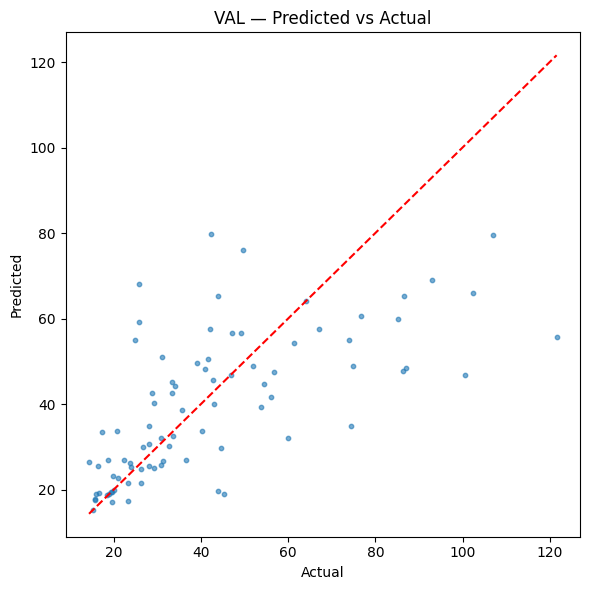

[Saved] /kaggle/working/xgb_playbook_split_fixed/test_pred_vs_actual.png


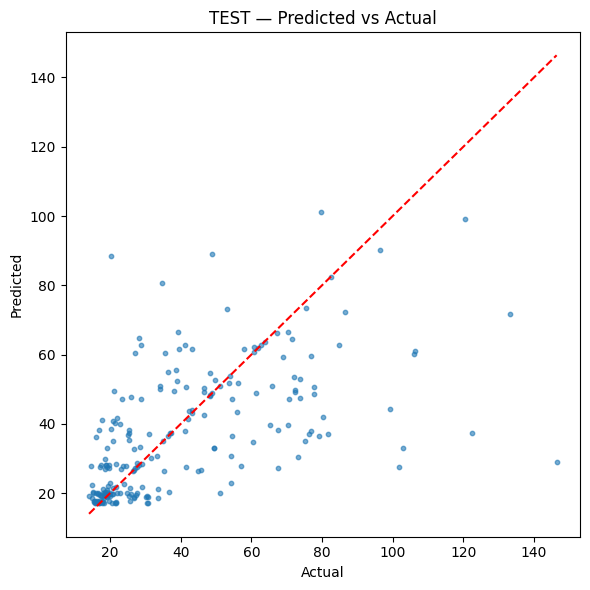

[Saved] /kaggle/working/xgb_playbook_split_fixed/val_timeseries.png


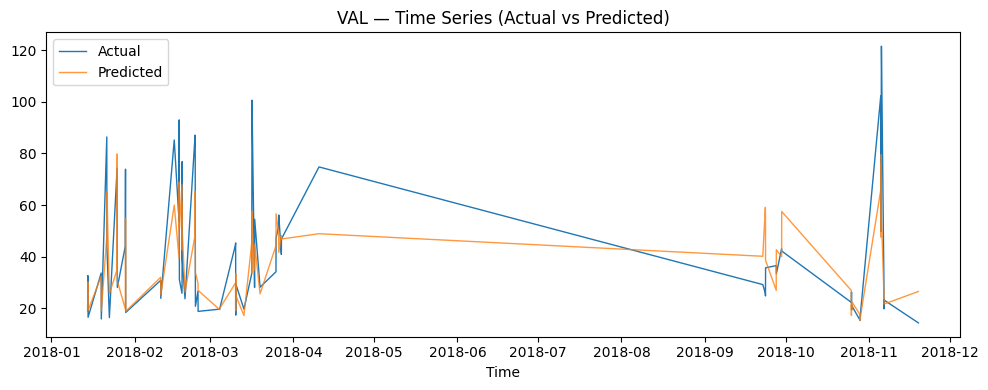

[Saved] /kaggle/working/xgb_playbook_split_fixed/test_timeseries.png


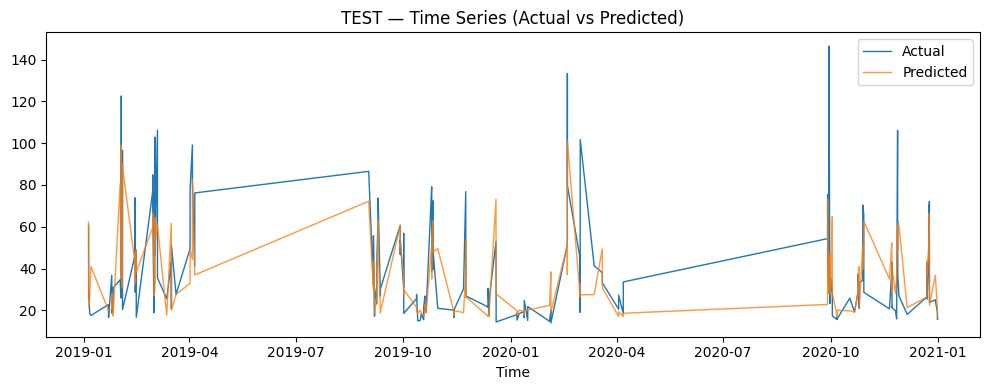

[Saved] /kaggle/working/xgb_playbook_split_fixed/val_residuals.png


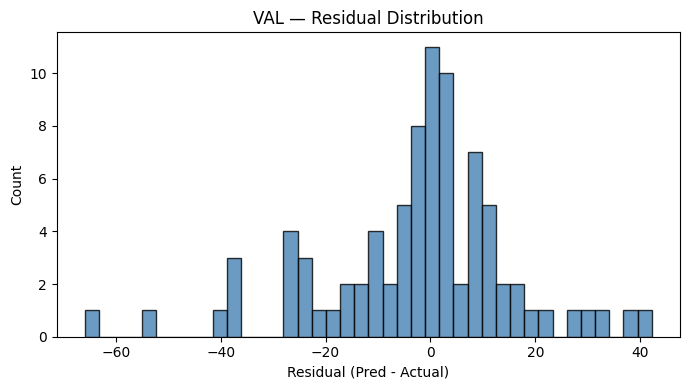

[Saved] /kaggle/working/xgb_playbook_split_fixed/test_residuals.png


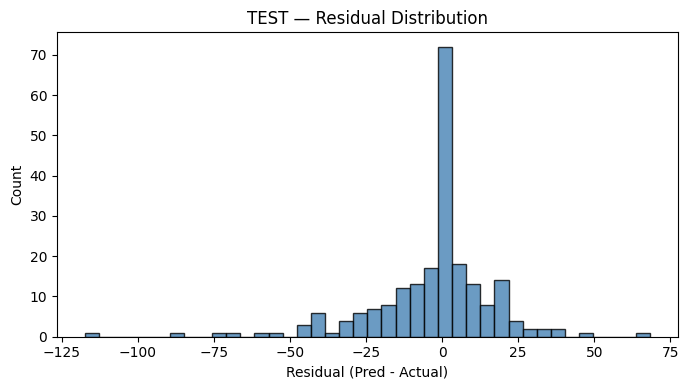

[Saved] /kaggle/working/xgb_playbook_split_fixed/feature_importance_top15.png


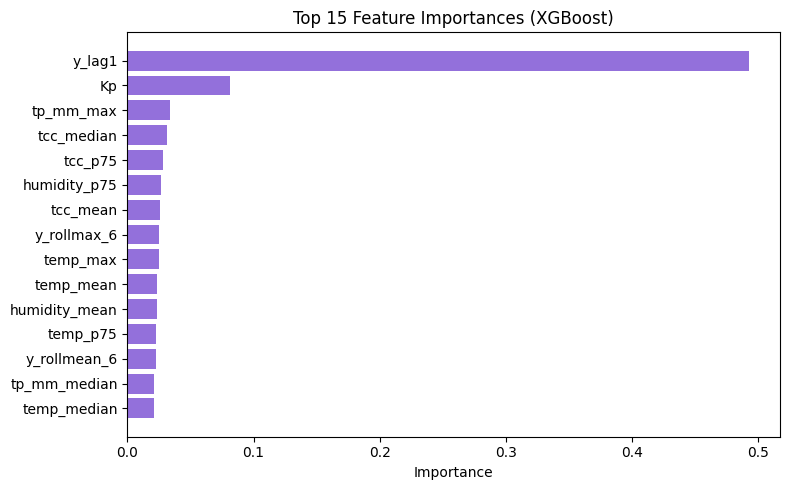


✅ All extended plots generated and saved to: /kaggle/working/xgb_playbook_split_fixed


In [2]:
# XGBoost_Playbook_Aligned_Full_v2.py
# -------------------------------------------------------------
# Aurora Forecasting via GPU-accelerated XGBoost
# Train=2012–2017 | Val=2018 | Test=2019–2020
# Includes AR/rolling features, log1p+winsor, tail reweighting,
# combo_mae selection, smearing, DTW, F1@q, full visuals.
# -------------------------------------------------------------

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, make_scorer
)
from xgboost import XGBRegressor
from scipy.stats import pearsonr

# -------------------------------------------------------------
# 0) Config
# -------------------------------------------------------------
DATA_PATH = "/kaggle/input/final-planb-24-final/final-planb-24 (1).csv"
TIME_COL = "time"
TARGET_COL = "keogram_mean"
DROP_COLS = ["time", "keogram_mean", "keogram_median", "keogram_max"]

SAVE_DIR = "/kaggle/working/xgb_playbook_split_fixed"
os.makedirs(SAVE_DIR, exist_ok=True)

# Feature / Target engineering knobs
AR_LAGS = [1]
ROLL_WINDOWS = [6]
WINSOR_Q = 0.995
LOG1P_TARGET = True
TAIL_REF_Q, TAIL_ALPHA, TAIL_GAMMA = 0.96, 12, 5
LAM_COMBO = 0.7

# GPU-friendly setup
GPU_PARAMS = dict(tree_method="hist", device="cuda")  # use new XGBoost 2.0+ syntax
RANDOM_STATE = 42

# -------------------------------------------------------------
# 1) Load data & prepare splits
# -------------------------------------------------------------
df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df = df.sort_values(TIME_COL).reset_index(drop=True)
print(f"Loaded: {DATA_PATH} | Shape={df.shape}")
print("Time range:", df[TIME_COL].min(), "→", df[TIME_COL].max())

# Split rules
train_idx = df[(df["time"] < "2018-01-01")].index
val_idx   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].index
test_idx  = df[(df["time"] >= "2019-01-01") & (df["time"] < "2021-01-01")].index

print("Split sizes:",
      "Train =", len(train_idx),
      "Val =", len(val_idx),
      "Test =", len(test_idx))

# -------------------------------------------------------------
# 2) Feature engineering (AR + rolling, shift(1) to avoid leakage)
# -------------------------------------------------------------
df_feat = df.copy()
y = df_feat[TARGET_COL].astype(float)

for lag in AR_LAGS:
    df_feat[f"y_lag{lag}"] = y.shift(lag)
for w in ROLL_WINDOWS:
    df_feat[f"y_rollmean_{w}"] = y.rolling(w).mean().shift(1)
    df_feat[f"y_rollmax_{w}"] = y.rolling(w).max().shift(1)

df_feat = df_feat.dropna().reset_index(drop=True)

# Redo splits on feature-complete dataframe
train_df = df_feat[df_feat["time"] < "2018-01-01"]
val_df   = df_feat[(df_feat["time"] >= "2018-01-01") & (df_feat["time"] < "2019-01-01")]
test_df  = df_feat[(df_feat["time"] >= "2019-01-01") & (df_feat["time"] < "2021-01-01")]


X_cols = [c for c in df_feat.columns if c not in DROP_COLS]
X_train, X_val, X_test = train_df[X_cols], val_df[X_cols], test_df[X_cols]
y_train_raw, y_val_raw, y_test_raw = (
    train_df[TARGET_COL].values.astype(float),
    val_df[TARGET_COL].values.astype(float),
    test_df[TARGET_COL].values.astype(float),
)
t_val, t_test = val_df["time"].values, test_df["time"].values

# -------------------------------------------------------------
# 3) Winsorization + log1p
# -------------------------------------------------------------
cap = np.quantile(y_train_raw, WINSOR_Q)
y_train_cap = np.minimum(y_train_raw, cap)
y_val_cap   = np.minimum(y_val_raw, cap)
y_test_cap  = np.minimum(y_test_raw, cap)

fwd, inv = np.log1p, np.expm1 if LOG1P_TARGET else (lambda x: x, lambda x: x)
y_train_t, y_val_t, y_test_t = fwd(y_train_cap), fwd(y_val_cap), fwd(y_test_cap)

# -------------------------------------------------------------
# 4) Tail reweighting (train)
# -------------------------------------------------------------
ranks = pd.Series(y_train_raw).rank(pct=True)
boost_zone = np.clip((ranks - TAIL_REF_Q) / (1 - TAIL_REF_Q), 0, 1)
weights = 1 + TAIL_ALPHA * (boost_zone ** TAIL_GAMMA)
weights = weights.values.astype(float)

# -------------------------------------------------------------
# 5) Custom combo_mae scorer (raw scale)
# -------------------------------------------------------------
def combo_mae_raw(y_true_raw, y_pred_raw, lam=LAM_COMBO):
    q90 = np.quantile(y_true_raw, 0.9)
    mask = y_true_raw > q90
    mae_all = mean_absolute_error(y_true_raw, y_pred_raw)
    mae_tail = mean_absolute_error(y_true_raw[mask], y_pred_raw[mask]) if np.any(mask) else mae_all
    return lam * mae_all + (1 - lam) * mae_tail

def combo_scorer_func(y_true_t, y_pred_t):
    y_true_raw, y_pred_raw = inv(y_true_t), inv(y_pred_t)
    return -combo_mae_raw(y_true_raw, y_pred_raw)

combo_scorer = make_scorer(lambda yt, yp: combo_scorer_func(yt, yp), greater_is_better=False)

# -------------------------------------------------------------
# 6) Model (GPU XGBoost) + RandomizedSearchCV
# -------------------------------------------------------------
base_xgb = XGBRegressor(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    reg_alpha=1,
    reg_lambda=3,
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    **GPU_PARAMS
)

pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base_xgb)])

param_space = {
    "xgb__n_estimators": [600, 900, 1200],
    "xgb__max_depth": [6, 8, 10],
    "xgb__learning_rate": [0.03, 0.05, 0.08],
    "xgb__subsample": [0.7, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.9, 1.0],
}

tscv = TimeSeriesSplit(n_splits=2)
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_space,
    n_iter=20,
    cv=tscv,
    scoring=combo_scorer,
    refit=True,
    verbose=1,
    random_state=RANDOM_STATE,
)

search.fit(X_train, y_train_t, xgb__sample_weight=weights)
print("Best params:", search.best_params_)
print(f"Best CV combo_mae (raw): {-search.best_score_:.4f}")

best_model = search.best_estimator_

# -------------------------------------------------------------
# 7) Smearing correction (bin)
# -------------------------------------------------------------
def smearing_bin(y_true_t, y_pred_t, bins=20):
    """Bin-based smearing correction: adjust inverse predictions by per-bin median ratios."""
    df_tmp = pd.DataFrame({"true_t": y_true_t, "pred_t": y_pred_t})
    df_tmp["bin"] = pd.qcut(df_tmp["pred_t"], q=bins, duplicates="drop")
    inv_true = inv(df_tmp["true_t"].values)
    inv_pred = inv(df_tmp["pred_t"].values)
    df_tmp["inv_true"] = inv_true
    df_tmp["inv_pred"] = inv_pred

    # Compute median true/pred ratio per bin
    factors = (
        df_tmp.groupby("bin", observed=False)
        .apply(lambda g: np.median(g["inv_true"] / np.clip(g["inv_pred"], 1e-9, None)))
    )

    # Map and ensure float dtype
    df_tmp["factor"] = df_tmp["bin"].map(factors).astype(float)

    # Apply correction
    smeared = inv_pred * df_tmp["factor"].to_numpy(dtype=float)
    return smeared


val_pred_t = best_model.predict(X_val)
test_pred_t = best_model.predict(X_test)
val_pred_raw = smearing_bin(y_val_t, val_pred_t)
test_pred_raw = smearing_bin(y_test_t, test_pred_t)

# -------------------------------------------------------------
# 8) Evaluation (RMSE, MAE, R2, Pearson, DTW, etc.)
# -------------------------------------------------------------
def dtw_distance(a, b):
    a, b = np.asarray(a), np.asarray(b)
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m] / (n + m)

def f1_at_quantile(y_true, y_pred, q=0.9):
    thresh = np.quantile(y_true, q)
    y_true_pos = y_true > thresh
    y_pred_pos = y_pred > thresh
    tp = np.sum(y_true_pos & y_pred_pos)
    fp = np.sum(~y_true_pos & y_pred_pos)
    fn = np.sum(y_true_pos & ~y_pred_pos)
    prec = tp / (tp + fp + 1e-9)
    rec = tp / (tp + fn + 1e-9)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return f1, prec, rec

def eval_split(name, y_true, y_pred, y_train):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    dtw = dtw_distance(y_true, y_pred)
    f1, p, rc = f1_at_quantile(y_true, y_pred, q=0.9)
    combo = combo_mae_raw(y_true, y_pred, lam=LAM_COMBO)
    print(f"{name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}, r={r:.3f}, DTW={dtw:.3f}, F1@q90={f1:.3f}")
    return dict(RMSE=rmse, MAE=mae, R2=r2, Pearson=r, DTW=dtw, F1=f1, ComboMAE=combo, y_pred=y_pred)

VAL = eval_split("VAL", y_val_raw, val_pred_raw, y_train_raw)
TEST = eval_split("TEST", y_test_raw, test_pred_raw, y_train_raw)

# -------------------------------------------------------------
# 9) Extended Visualizations (all plots printed inline + saved)
# -------------------------------------------------------------
def save_and_show(fig, path):
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    print(f"[Saved] {path}")
    plt.show()

# --- Predicted vs Actual ---
def plot_pred_vs_actual_all(y_true, y_pred, split, save_path):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)
    mmin, mmax = float(y_true.min()), float(y_true.max())
    plt.plot([mmin, mmax], [mmin, mmax], "r--")
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.title(f"{split} — Predicted vs Actual")
    save_and_show(plt, save_path)

# --- Time Series ---
def plot_time_series_all(t, y_true, y_pred, split, save_path):
    plt.figure(figsize=(10,4))
    plt.plot(t, y_true, label="Actual", linewidth=1)
    plt.plot(t, y_pred, label="Predicted", linewidth=1, alpha=0.8)
    plt.legend(); plt.xlabel("Time")
    plt.title(f"{split} — Time Series (Actual vs Predicted)")
    save_and_show(plt, save_path)

# --- Residuals ---
def plot_residuals_all(y_true, y_pred, split, save_path):
    resid = y_pred - y_true
    plt.figure(figsize=(7,4))
    plt.hist(resid, bins=40, alpha=0.8, color='steelblue', edgecolor='k')
    plt.xlabel("Residual (Pred - Actual)")
    plt.ylabel("Count")
    plt.title(f"{split} — Residual Distribution")
    save_and_show(plt, save_path)

# --- Feature Importance ---
def plot_feature_importance(model, X_cols, save_path, top_n=15):
    booster = model.named_steps["xgb"] if isinstance(model, Pipeline) else model
    importances = booster.feature_importances_
    top_idx = np.argsort(importances)[::-1][:top_n]
    plt.figure(figsize=(8,5))
    plt.barh(np.array(X_cols)[top_idx][::-1], importances[top_idx][::-1], color='mediumpurple')
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances (XGBoost)")
    save_and_show(plt, save_path)

# -------------------------------------------------------------
# 10) Generate & show all plots
# -------------------------------------------------------------
plot_pred_vs_actual_all(y_val_raw, VAL["y_pred"], "VAL", os.path.join(SAVE_DIR, "val_pred_vs_actual.png"))
plot_pred_vs_actual_all(y_test_raw, TEST["y_pred"], "TEST", os.path.join(SAVE_DIR, "test_pred_vs_actual.png"))

plot_time_series_all(t_val, y_val_raw, VAL["y_pred"], "VAL", os.path.join(SAVE_DIR, "val_timeseries.png"))
plot_time_series_all(t_test, y_test_raw, TEST["y_pred"], "TEST", os.path.join(SAVE_DIR, "test_timeseries.png"))

plot_residuals_all(y_val_raw, VAL["y_pred"], "VAL", os.path.join(SAVE_DIR, "val_residuals.png"))
plot_residuals_all(y_test_raw, TEST["y_pred"], "TEST", os.path.join(SAVE_DIR, "test_residuals.png"))

plot_feature_importance(best_model, X_cols, os.path.join(SAVE_DIR, "feature_importance_top15.png"))

print("\n✅ All extended plots generated and saved to:", SAVE_DIR)


In [7]:
# =============================================================
# XGBoost (GPU-Optimized) — LOG-target + Winsor + Reweight + Combo Search
# Raw-scale scoring + timings + visuals + advanced metrics
# Dataset: Aurora Intensity (final-planb-24)
# Environment: Kaggle (GPU T4 ×2)
# Author: Group 10 (COMPSCI 760)
# =============================================================

import os, time
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, make_scorer
)
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# =============================================================
# 0) CONFIGURATION
# =============================================================
PIPELINE_MODE = True
REFIT_METRIC = "combo_mae"
LAM_COMBO = 0.7

FAST_MODE = True
CPU_COUNT = os.cpu_count() or 2
N_JOBS = min(4, CPU_COUNT)
N_SPLITS = 2 if FAST_MODE else 3
N_ITER = 25 if FAST_MODE else 60
SAVE_DIR = "/kaggle/working/figs_xgb_combo"
os.makedirs(SAVE_DIR, exist_ok=True)

# Target transforms and weighting
USE_WINSOR_Y = True
Y_WINSOR_UP_Q = 0.995
USE_LOG1P_TARGET = True
USE_REWEIGHT = True
REWEIGHT_REF_Q = 0.96
REWEIGHT_ALPHA = 12.0
REWEIGHT_GAMMA = 5.0

# Smearing correction
USE_SMEARING = True
SMEARING_MODE = "bin"
SMEARING_BINS = 12

# DTW comparison settings
DTW_MODE = "per_step"

# Timing helper
timings = {}
def tic(): return time.perf_counter()
def toc(t0): return time.perf_counter() - t0
def timed(key, fn, *a, **kw):
    t0 = tic(); out = fn(*a, **kw); timings[key] = toc(t0)
    print(f"[Timing] {key}: {timings[key]:.2f}s")
    return out

# =============================================================
# 1) LOAD DATA (KAGGLE PATH)
# =============================================================
CSV_PATH = "/kaggle/input/final-planb-24-final/final-planb-24 (1).csv"
print(f"Loading dataset: {CSV_PATH}")
df = pd.read_csv(CSV_PATH, parse_dates=["time"])
print(f"Loaded shape = {df.shape}")
print(f"Time range = {df['time'].min()} → {df['time'].max()}")

TARGET_COL = "keogram_mean"
df = df.dropna(subset=[TARGET_COL]).sort_values("time")

# Autoregressive features (no leakage)
df["y_lag1"] = df[TARGET_COL].shift(1)
df["y_rollmean_6"] = df[TARGET_COL].rolling(6, min_periods=1).mean().shift(1)
df["y_rollmax_6"] = df[TARGET_COL].rolling(6, min_periods=1).max().shift(1)

drop_cols = ["time", "keogram_mean", "keogram_median", "keogram_max"]
features = [c for c in df.columns if c not in drop_cols]
X_all = df[features]
y_all_raw = df[TARGET_COL].values

# Time-based split
train_idx = df[df["time"] < "2018-01-01"].index
val_idx   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].index
test_idx  = df[(df["time"] >= "2019-01-01") & (df["time"] < "2021-01-01")].index

print("Split sizes:",
      f"Train={len(train_idx)} | Val={len(val_idx)} | Test={len(test_idx)}")

X_train_df, X_val_df, X_test_df = (
    X_all.loc[train_idx], X_all.loc[val_idx], X_all.loc[test_idx]
)
y_train_raw = df.loc[train_idx, TARGET_COL].values
y_val_raw   = df.loc[val_idx, TARGET_COL].values
y_test_raw  = df.loc[test_idx, TARGET_COL].values
t_val  = df.loc[val_idx, "time"].to_numpy()
t_test = df.loc[test_idx, "time"].to_numpy()

# =============================================================
# 2) TARGET PROCESSING
# =============================================================
def _fwd(y): return np.log1p(y) if USE_LOG1P_TARGET else y
def _inv(y): return np.expm1(y) if USE_LOG1P_TARGET else y

if USE_WINSOR_Y:
    cap = np.quantile(y_train_raw, Y_WINSOR_UP_Q)
    y_train_cap = np.minimum(y_train_raw, cap)
    y_val_cap   = np.minimum(y_val_raw, cap)
    y_test_cap  = np.minimum(y_test_raw, cap)
else:
    y_train_cap, y_val_cap, y_test_cap = y_train_raw, y_val_raw, y_test_raw

y_train_t = _fwd(y_train_cap)
y_val_t   = _fwd(y_val_cap)
y_test_t  = _fwd(y_test_cap)

# Tail reweighting
if USE_REWEIGHT:
    ranks = pd.Series(y_train_raw).rank(pct=True)
    boost = np.clip((ranks - REWEIGHT_REF_Q) / (1 - REWEIGHT_REF_Q), 0, 1)
    sample_weight_train = 1 + REWEIGHT_ALPHA * (boost ** REWEIGHT_GAMMA)
else:
    sample_weight_train = None

# =============================================================
# 3) SCORING FUNCTIONS (raw-scale)
# =============================================================
def _to_raw(y): return _inv(y) if USE_LOG1P_TARGET else y
def _raw_mae(y_true, y_pred): return -mean_absolute_error(_to_raw(y_true), _to_raw(y_pred))
def _tail_mae(y_true, y_pred, q=0.9):
    ytr, ypr = _to_raw(y_true), _to_raw(y_pred)
    thr = np.quantile(ytr, q)
    mask = ytr >= thr
    return -mean_absolute_error(ytr[mask], ypr[mask])
def _combo_mae(y_true, y_pred, lam=LAM_COMBO):
    return -(lam * -_raw_mae(y_true, y_pred) + (1 - lam) * -_tail_mae(y_true, y_pred))

RAW_MAE = make_scorer(_raw_mae, greater_is_better=True)
TAIL_MAE = make_scorer(lambda yt, yp: _tail_mae(yt, yp), greater_is_better=True)
COMBO_MAE = make_scorer(lambda yt, yp: _combo_mae(yt, yp), greater_is_better=True)
scoring = {"raw_mae": RAW_MAE, "tail_mae": TAIL_MAE, "combo_mae": COMBO_MAE}

# =============================================================
# 4) MODEL + GPU-ENABLED CV SEARCH
# =============================================================
def _make_estimator_xgb():
    base = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",      # use hist, device=cuda replaces gpu_hist
        predictor="gpu_predictor",
        device="cuda",
        random_state=42,
        n_jobs=N_JOBS
    )
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base)]) if PIPELINE_MODE else base

_prefix = lambda p: f"xgb__{p}" if PIPELINE_MODE else p
param_grid = {
    _prefix("n_estimators"): [300, 600, 900] if FAST_MODE else [400, 800, 1200],
    _prefix("max_depth"): [4, 6, 8],
    _prefix("learning_rate"): [0.03, 0.05, 0.1],
    _prefix("subsample"): [0.8, 1.0],
    _prefix("colsample_bytree"): [0.8, 1.0],
    _prefix("gamma"): [0, 0.5, 1],
    _prefix("reg_lambda"): [1, 5, 10],
    _prefix("reg_alpha"): [0, 1, 5]
}

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
fitkw = {"xgb__sample_weight": sample_weight_train} if (PIPELINE_MODE and USE_REWEIGHT) else (
    {"sample_weight": sample_weight_train} if USE_REWEIGHT else {}
)

print("\n[Search] GPU XGBoost combo search (T4 ×2) ...")
search = RandomizedSearchCV(
    estimator=_make_estimator_xgb(),
    param_distributions=param_grid,
    n_iter=N_ITER,
    cv=tscv,
    scoring=scoring,
    refit=REFIT_METRIC,
    verbose=1,
    n_jobs=N_JOBS,
    random_state=42
)
timed("search_fit", search.fit, X_train_df, y_train_t, **fitkw)
best_est = search.best_estimator_
print("Best params:", search.best_params_)
print(f"Best CV combo_mae: {-search.best_score_:.4f}")

# =============================================================
# 5) SMEARING CORRECTION
# =============================================================
smearing = {"mode": "off"}
if USE_SMEARING and USE_LOG1P_TARGET:
    train_pred_t = best_est.predict(X_train_df)
    eps = y_train_t - train_pred_t
    if SMEARING_MODE == "global":
        smearing = {"mode": "global", "global": float(np.mean(np.exp(eps)))}
    else:
        q = np.quantile(train_pred_t, np.linspace(0, 1, SMEARING_BINS + 1))
        bins = np.unique(q)
        ids = np.digitize(train_pred_t, bins[1:-1])
        facs = []
        for b in range(len(bins)-1):
            mask = ids == b
            facs.append(float(np.mean(np.exp(eps[mask]))) if mask.any() else 1.0)
        smearing = {"mode": "bin", "bins": bins.tolist(), "factors": facs}

def _apply_smear(pred_t, sm):
    y = np.expm1(pred_t)
    if sm.get("mode") == "global":
        return y * sm["global"]
    if sm.get("mode") == "bin":
        bins = np.array(sm["bins"]); facs = np.array(sm["factors"])
        ids = np.digitize(pred_t, bins[1:-1])
        ids = np.clip(ids, 0, len(facs)-1)
        return y * facs[ids]
    return y

# =============================================================
# 6) EVALUATION + METRICS
# =============================================================
try:
    from fastdtw import fastdtw
    _use_fdtw = True
except:
    _use_fdtw = False

def _pearson(a, b):
    a, b = np.asarray(a), np.asarray(b)
    m = np.isfinite(a) & np.isfinite(b)
    return np.corrcoef(a[m], b[m])[0, 1] if m.sum() > 1 else np.nan

def _dtw(a, b):
    a, b = np.asarray(a), np.asarray(b)
    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m], b[m]
    if _use_fdtw:
        d, _ = fastdtw(a, b, dist=lambda x, y: abs(x - y))
    else:
        n, m = len(a), len(b)
        D = np.full((n + 1, m + 1), np.inf)
        D[0, 0] = 0
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                cost = abs(a[i - 1] - b[j - 1])
                D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
        d = D[n, m]
    return d / len(a) if DTW_MODE == "per_step" else d

def _eval(split, y_true_raw, y_pred_t):
    y_pred_raw = _apply_smear(y_pred_t, smearing) if (USE_SMEARING and USE_LOG1P_TARGET) else _inv(y_pred_t)
    mse = mean_squared_error(y_true_raw, y_pred_raw)
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    r2 = r2_score(y_true_raw, y_pred_raw)
    pear = _pearson(y_true_raw, y_pred_raw)
    dtw = _dtw(y_true_raw, y_pred_raw)
    thr = np.quantile(y_true_raw, 0.9)
    yb, yp = (y_true_raw >= thr).astype(int), (y_pred_raw >= thr).astype(int)
    f1 = f1_score(yb, yp, zero_division=0)
    print(f"{split}: RMSE={np.sqrt(mse):.3f}  MAE={mae:.3f}  R2={r2:.3f}  Pearson={pear:.3f}  DTW={dtw:.3f}  F1@q90={f1:.3f}")
    return dict(RMSE=np.sqrt(mse), MAE=mae, R2=r2, Pearson=pear, DTW=dtw, F1_q90=f1)

val_pred_t  = best_est.predict(X_val_df)
test_pred_t = best_est.predict(X_test_df)
val_metrics  = _eval("VAL ", y_val_raw, val_pred_t)
test_metrics = _eval("TEST", y_test_raw, test_pred_t)

# =============================================================
# 7) VISUALS + SAVE RESULTS
# =============================================================
def _savefig(path): plt.tight_layout(); plt.savefig(path, dpi=150); plt.close(); print("[Saved]", path)

val_pred_raw  = _apply_smear(val_pred_t, smearing)
test_pred_raw = _apply_smear(test_pred_t, smearing)

# --- VAL ---
if len(t_val) != len(y_val_raw):
    print("[WARN] VAL time axis mismatch — using indices.")
    t_val = np.arange(len(y_val_raw))
plt.figure(figsize=(10,4))
plt.plot(t_val, y_val_raw, label="Actual")
plt.plot(t_val, val_pred_raw, label="Predicted")
plt.legend(); plt.title("VAL — Time Series")
_savefig(os.path.join(SAVE_DIR, "val_timeseries.png"))

# --- TEST ---
if len(t_test) != len(y_test_raw):
    print("[WARN] TEST time axis mismatch — using indices.")
    t_test = np.arange(len(y_test_raw))
plt.figure(figsize=(10,4))
plt.plot(t_test, y_test_raw, label="Actual")
plt.plot(t_test, test_pred_raw, label="Predicted")
plt.legend(); plt.title("TEST — Time Series")
_savefig(os.path.join(SAVE_DIR, "test_timeseries.png"))

# --- Scatter plots ---
plt.figure(figsize=(6,6))
plt.scatter(y_val_raw, val_pred_raw, s=10, alpha=0.6)
plt.plot([y_val_raw.min(), y_val_raw.max()], [y_val_raw.min(), y_val_raw.max()], "--")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("VAL — Pred vs Actual")
_savefig(os.path.join(SAVE_DIR, "val_pred_vs_actual.png"))

plt.figure(figsize=(6,6))
plt.scatter(y_test_raw, test_pred_raw, s=10, alpha=0.6)
plt.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], "--")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("TEST — Pred vs Actual")
_savefig(os.path.join(SAVE_DIR, "test_pred_vs_actual.png"))

# --- Save metrics ---
pd.DataFrame([val_metrics, test_metrics], index=["VAL","TEST"]).to_csv(
    os.path.join(SAVE_DIR, "metrics_summary.csv")
)
print("\n✅ Done. GPU XGBoost run completed successfully.")


Loading dataset: /kaggle/input/final-planb-24-final/final-planb-24 (1).csv
Loaded shape = (78957, 23)
Time range = 2012-01-01 00:00:00 → 2021-01-01 05:00:00
Split sizes: Train=7430 | Val=849 | Test=1865

[Search] GPU XGBoost combo search (T4 ×2) ...
Fitting 2 folds for each of 25 candidates, totalling 50 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [09:13:33] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [09:13:33] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [09:13:33] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [09:13:33] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [09:13:42] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "predictor" } are not used.

  warnings.warn

[Timing] search_fit: 90.43s
Best params: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 5, 'xgb__reg_alpha': 5, 'xgb__n_estimators': 900, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.05, 'xgb__gamma': 1, 'xgb__colsample_bytree': 0.8}
Best CV combo_mae: 26.1709
VAL : RMSE=20.824  MAE=13.905  R2=0.363  Pearson=0.607  DTW=8.418  F1@q90=0.397
TEST: RMSE=19.624  MAE=13.541  R2=0.302  Pearson=0.577  DTW=7.815  F1@q90=0.428
[Saved] /kaggle/working/figs_xgb_combo/val_timeseries.png
[Saved] /kaggle/working/figs_xgb_combo/test_timeseries.png
[Saved] /kaggle/working/figs_xgb_combo/val_pred_vs_actual.png
[Saved] /kaggle/working/figs_xgb_combo/test_pred_vs_actual.png

✅ Done. GPU XGBoost run completed successfully.
